# Introduction

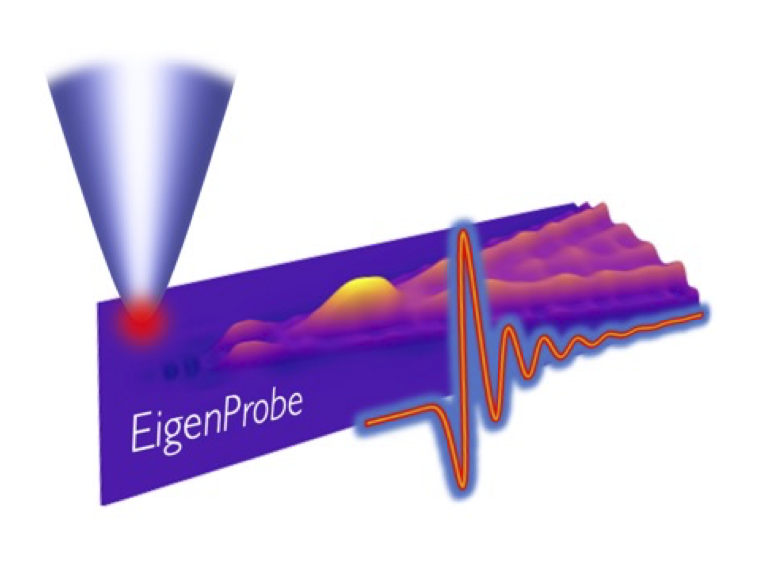

In [1]:
from IPython.display import Image
Image("../Documentation/EigenProbe_Logo.png",width=500)

Here we will achieve the following goals.  [TODO]

# Imports

## General Imports

In [1]:
import os,time,sys,pickle
from matplotlib import pyplot as plt
import numpy as np
import copy

plt.rcParams['figure.figsize'] = [8, 5] # "Long" plot figures will be convenient here.

## Specialized Imports

In [2]:
from EigenProbe.common.baseclasses import AWA # https://github.com/asmcleod/common.git
from EigenProbe.common.misc import flatten
from EigenProbe.common import numerical_recipes as numrec
from EigenProbe import common

sys.modules['common'] = common # This hook allows to continue to load probe files that were previously saved under an older alias for `common`

## EigenProbe tools

In [3]:
import EigenProbe as EP # https://github.com/asmcleod/EigenProbe.git
from EigenProbe import RotationalMoM as RotMOM
from EigenProbe import ProbeSpectroscopy as PS
from EigenProbe import EigenInversion as EI
from EigenProbe import Materials as M

sys.modules['ProbeCavityEigenfields'] = EP # This hook allows to continue to load probe files that were previously saved under an older alias for `EigenProbe`

<plotting>:
	Registered colormaps "Warm" and "Warm_r"...
<plotting>:
	Registered colormaps "vanheum" and "vanheum_r"...
<plotting>:
	Registered colormaps "NT-MDT" and "NT-MDT_r"...
<plotting>:
<plotting>:
	Registered colormaps "jingdi" and "jingdi_r"...
<plotting>:
	Registered colormaps "Halcyon" and "Halcyon_r"...
<plotting>:
	Registered colormaps "Cold" and "Cold_r"...
<plotting>:
	Registered colormaps "Sky" and "Sky_r"...
<plotting>:
	Registered colormaps "Gwyddion.net" and "Gwyddion.net_r"...
<plotting>:
	Registered colormaps "BlueRed" and "BlueRed_r"...
<plotting>:
	Registered colormaps "vanheum3" and "vanheum3_r"...
<plotting>:
	Registered colormaps "vanheum2" and "vanheum2_r"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "Bi2Se3_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	<material_types.TabulatedMaterialFromFile.__init__>:
		Loading tabulated material data from file "PMMA_epsilon.pickle"...
<mater

# Build / load the needed simulation tools

In [4]:
Nmodes = 15 # All prediction tools will use this number of eigenmodes

## Build / load probe

In [5]:
a_nm=20 # probe radius in nanometers
a=a_nm*1e-7 #in cm
L=24e-4 #probe length in cm, assuming added cantilever thickness 4e-4 #Arrow probe: https://www.nanoworld.com/tapping-mode-reflex-coated-afm-tip-arrow-ncr
L_microns=L*1e4
taper_angle=21 # Arrow probe: https://www.researchgate.net/figure/SEM-image-of-an-AFM-tip-attached-to-cantilever_fig6_224406883
geometry='hyperboloid'

WL_THz=300e-4 #300 microns wavelength
freq_THz=1/WL_THz
freq=30*freq_THz # 30 THz

Nsubnodes=2 # 2 or 4 are common values; can be any integer number, but greater than four gains questionably more accuracy and adds great expense.  Experience shows 2 is usually sufficient.
Nnodes=244 # 244 is a good balance of cost and accuracy.  The number will be coerced to the nearest available quadrature grid length.
EP.Probe.dtype = np.complex64

probe_name = '%s_a=%inm_taper=%i_L=%imicrons_Nnodes=%i'%(geometry.capitalize(),a_nm,taper_angle,L_microns,Nnodes)
#probe_name = 'MidIRHyperboloid_FreqDepNormalization_L=%imicrons'%(L*1e4,)
print('Building probe %s...'%probe_name)

Building probe Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244...


Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"...
<__init__._ProbesCollection.__setitem__>:
	<__init__._ProbesCollection.__setitem__>:
		Registering probe "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244"...
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"!


Text(0, 0.5, 'z (cm)')

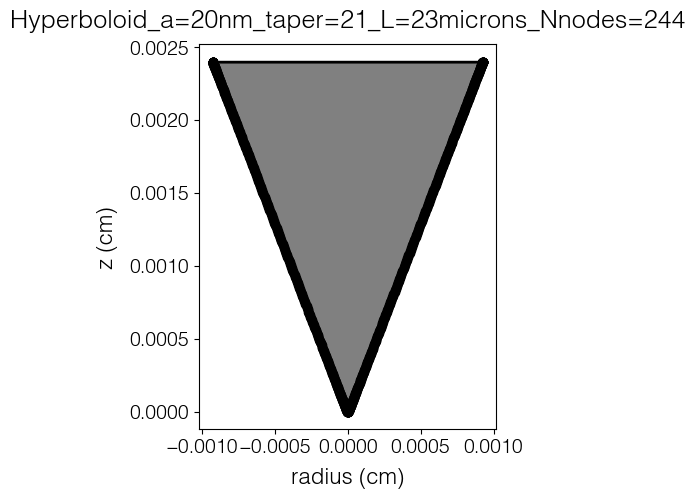

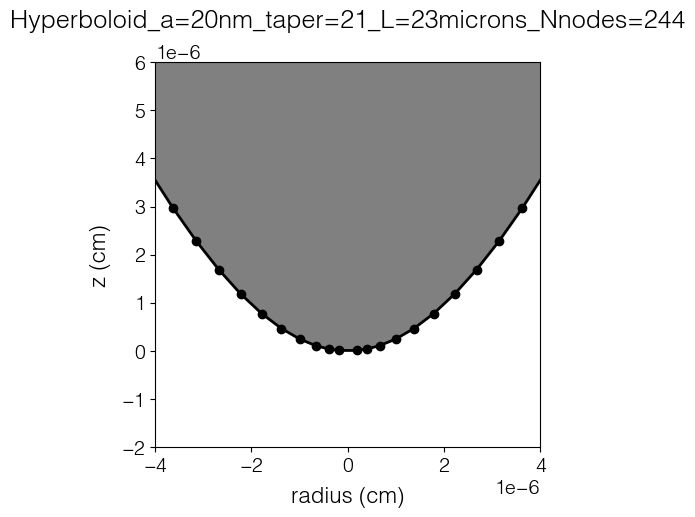

In [6]:
# Load the probe or build the probe
recompute = False
overwrite = False
try:
    if recompute: raise ValueError
    P = EP.load(probe_name,EP.Probe)
except (FileNotFoundError,ValueError): 

    P=EP.Probe(Nnodes=Nnodes,Nsubnodes=Nsubnodes,L=L,quadrature=numrec.TS,\
                     a=a,taper_angle=taper_angle,geometry=geometry,
                freq=freq,gap=a,name=probe_name)

    RotMOM.quadlimit = int(1e4) # maximum evaluations of interaction kernel per node of probe
    #Zmirror = P.get_mirror_impedance(k=0,kappa_min=.1/L,recompute=False,sommerfeld=True,Nkappas=244*8)
    Zmirror = P.get_mirror_impedance(sommerfeld=False)
    #Zself = P.get_self_impedance(k=P.get_k(),recompute=True)
    rhos,Js = P.solve_eigenmodes(condition_ZM=True,condition_ZS=False,ZMthresh=0,recompute_impedance=False)
    
    try: EP.save(P,overwrite=overwrite)
    except OSError: pass
    
ztip=P.get_gap()
zs=P.get_zs()
Rs=P.get_radii()
k=P.get_k()

P.plot_geometry()
plt.gca().set_aspect('equal')
plt.xlabel('radius (cm)')
plt.ylabel('z (cm)')

P.plot_geometry()
plt.xlim(-2*a,2*a)
plt.ylim(-a,3*a)
plt.xlabel('radius (cm)')
plt.ylabel('z (cm)')

#Zmirror = P.get_mirror_impedance(k=P.get_k(),nonsingular=False,recompute=True)
#Zmirror = P.get_mirror_impedance(k=0,nonsingular=False,recompute=True)
#Zmirror = P.get_mirror_impedance(k=P.get_k(),farfield=False,recompute=True,sommerfeld=True,Nkappas=244*8,rp=rp_au,\
#                                kappa_min=P.get_k()*.01)

(0.0, 15.0)

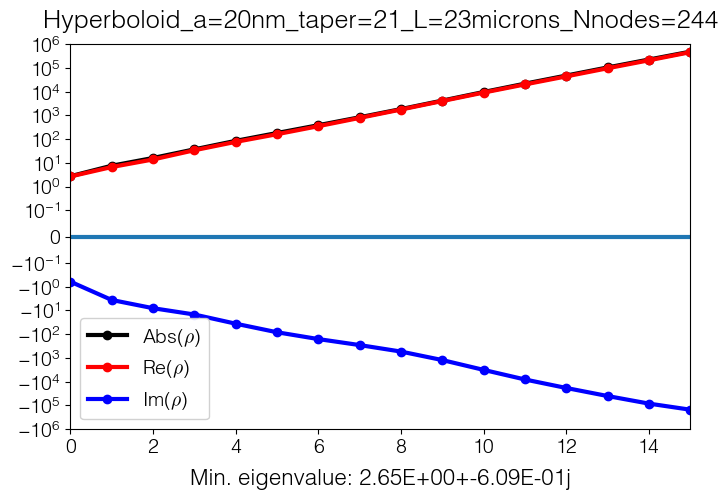

In [7]:
P.plot_eigenrhos()
plt.xlim(0,15)

## Build / load `ProbeGapSpectroscopy`

In [8]:
recompute=False
save=True
overwrite=False

#kwargs=dict(sommerfeld=True, kappa_max = None, Nkappas = 244*4 ) # adaptive kappa_max
kwargs=dict(sommerfeld=False,basis_gap = P.get_a()) # basis is important

try:
    if recompute: raise ValueError
    ProbeGapSpectroscopy = EP.load(P, PS.ProbeGapSpectroscopyParallel, overwrite_probe=True)
    
except (FileNotFoundError,ValueError):
    gaps = np.logspace(-1.5, 1.5, 100) * P.get_a() # gap values relative to probe radius
    ProbeGapSpectroscopy = PS.ProbeGapSpectroscopyParallel(Probe=P, gaps=gaps,
                                                        ncpus=8, backend='loky',
                                                        Nmodes=50, reversed=False,**kwargs)
    if save:
        try: EP.save(ProbeGapSpectroscopy,overwrite=overwrite)
        except OSError: # didn't overwrite
            print('Tried to save ProbeGapSpectroscopy, but save file already exists.  Skipping.  You can choose `overwrite=True`.')

Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_ProbeGapSpectroscopy.pickle"...
<__init__._ProbesCollection.__setitem__>:
	<__init__._ProbesCollection.__setitem__>:
		Overwriting registered probe "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244"...
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_ProbeGapSpectroscopy.pickle"!


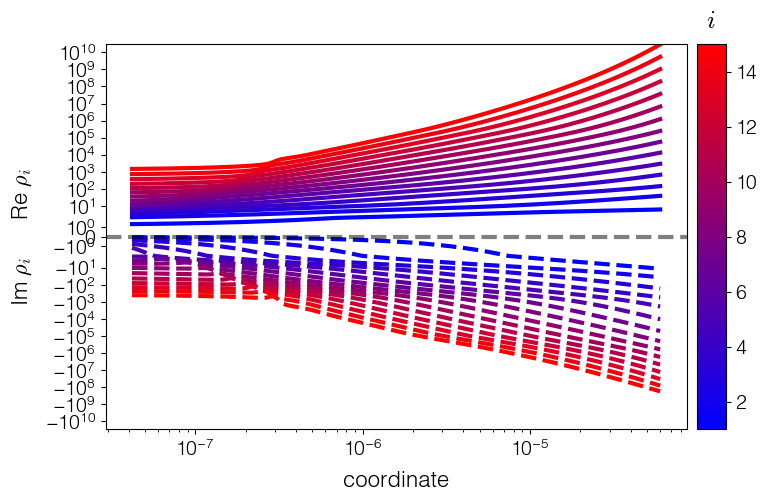

In [9]:
ProbeGapSpectroscopy.plot_eigenrhos(Nmodes=Nmodes)

## Build / load `EncodedEigenfields` from gap spectroscopy

In [10]:
recompute=False
save=True
overwrite=False

try:
    if recompute: raise ValueError
    EE = EP.load(P, PS.EncodedEigenfields, overwrite_probe=True)
    
except (FileNotFoundError,ValueError):
    gap0 = P.get_a()/10
    EE = PS.EncodedEigenfields(ProbeGapSpectroscopy,gap0=gap0, Nmodes=Nmodes,
                                kappa_min=None, kappa_max=20/a,
                                Nkappas=244*8, qquadrature=EP.numrec.GL)
    if save:
        try: EP.save(EE,overwrite=overwrite)
        except OSError: # didn't overwrite
            print('Tried to save EncodedEigenfields, but save file already exists.  Skipping.  You can choose `overwrite=True`.')

Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_EncodedEigenfields.pickle"...
<__init__._ProbesCollection.__setitem__>:
	<__init__._ProbesCollection.__setitem__>:
		Overwriting registered probe "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244"...
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_EncodedEigenfields.pickle"!


### Build library for quick calculation of 2D material contrast

The `EncodedEigenfields` can be used to extremely quickly compute interaction with a 2D material atop a bulk substrate.  Such interactions can be parameterized uniquely in terms of $q_p$ and $\varepsilon$, the (unscreened) polariton momentum and substrate permittivity, respectively.  To accomplish this fast calculation, it suffices to compute a "library" of reflection matrices $R_0\equiv R(q_p,\varepsilon,d_0)$ between the eigenmodes at gap coordinate $d_0$.  (Thanks to internal structure of the Fresnel coefficient for this geometry, it actually suffices to compute the library (only) over a grid of screened polariton momentum values $\bar{q}_p=q_p/\kappa$ with $\kappa\equiv (1+\varepsilon)/2$.)  The reflection matrix at other values of $d$ is now simply $R(q_p,\varepsilon,d)=\Phi^T(d) R_0 \Phi(d)$.

To compute the library of $R_0$, specify a grid of $|\bar{q}_p|$ values.  The calculator will automatically expand these values to all four needed quadrants of the complex plane.  (Interestingly, unlike complex-valued temporal frequencies, there is no apparent "upper half complex plane" constraint for $\bar{q}_p$.)

In [11]:
recompute=False
save=True
overwrite=False

if not hasattr(EE,'Rmat2D_interp_subs_r') or recompute:
    q0 = 1/EE.get_probe().get_a() # A typical scale for qp
    qps = np.logspace(-3, 2, 100) * q0
    EE.build_Rmat2D_library(qps,
                            interp_kwargs = dict(s=0,kx=1,ky=1)) # smoothing factor `s=0` is for interpolation, `kx` and `ky` are degrees of spline

    if save:
        try: EP.save(EE,overwrite=overwrite)
        except OSError: # didn't overwrite
            print('Tried to save EncodedEigenfields, but save file already exists.  Skipping.  You can choose `overwrite=True`.')

## Build / load `InvertibleEigenfields`

In [12]:
recompute=False
save=True
overwrite=False

try:
    if recompute: raise ValueError
    IE = EP.load(P, PS.InvertibleEigenfields, overwrite_probe=True)
    
except (FileNotFoundError,ValueError):
    IE = PS.InvertibleEigenfields(ProbeGapSpectroscopy, Nmodes=Nmodes,
                                   interpolation='cubic')
    if save:
        try: EP.save(IE,overwrite=overwrite)
        except OSError: # didn't overwrite
            print('Tried to save EncodedEigenfields, but save file already exists.  Skipping.  You can choose `overwrite=True`.')

Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_InvertibleEigenfields.pickle"...
Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"...
<__init__._ProbesCollection.__setitem__>:
	<__init__._ProbesCollection.__setitem__>:
		Overwriting registered probe "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244"...
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"!
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_InvertibleEigenfields.pickle"!


# Predict three exemplary spectra that will be treated as "measurement"

In [13]:
#-- None-interactive plotting
%matplotlib inline

## Parameters describing the "measurement"

In [14]:
a_nm = 20 # Physical dimension of probe radius, in nanometers
A_nm = 80 # Tapping amplitude, in nanometers
gapmin_nm = a_nm/10 # Physical dimension of minimum probe-sample distance, in nanometers
kappa_max=None #20/P.get_a() # Largest value of in-plane momentum (in Probe units) to use for internal momentum quadrature with Fresnel coefficient
Nkappas = 244*2 # Number of momentum quadrature points to use by default
Ngaps = 12 # Number of probe-sample gap nodesto use for computing demodulated scattering

sim_kwargs = dict(amplitude_nm=A_nm,gapmin_nm = gapmin_nm,a_nm=a_nm,Ngaps=Ngaps,Nmodes=Nmodes,harmonic=3)

freqs_wn=np.linspace(600,1350,100) # Energies at which all spectra will be measured

## An extremely fast predictor for demodulated scattering from layered media

In [15]:
# Set up a template to describe the medium we will be simulating / fitting dynamically
PMMA_thickness_nm = 20
thin_film_material = M.IsotropicMaterial()
substrate_material = M.IsotropicMaterial()
layered_medium = M.LayeredMediaTM((thin_film_material,PMMA_thickness_nm*1e-7),
                                   exit=substrate_material)
film_layer = layered_medium.get_layers()[0]

Predictor_S3_from_layer = EI.LayeredMediaEncodedEigenfieldsPredictor(EE,
                                                         layered_medium,film_layer,substrate_material,
                                                         qp_ref=None,
                                                         eps_ref=1e8,
                                                         **sim_kwargs)

/Users/alexandersmcleod/tools/python/EigenProbe/ProbeSpectroscopy.py:967: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Erads.append( complex(Erad) )


## Predict PMMA spectrum

Text(0.5, 0, 'Frequency [cm$^{-1}$]')

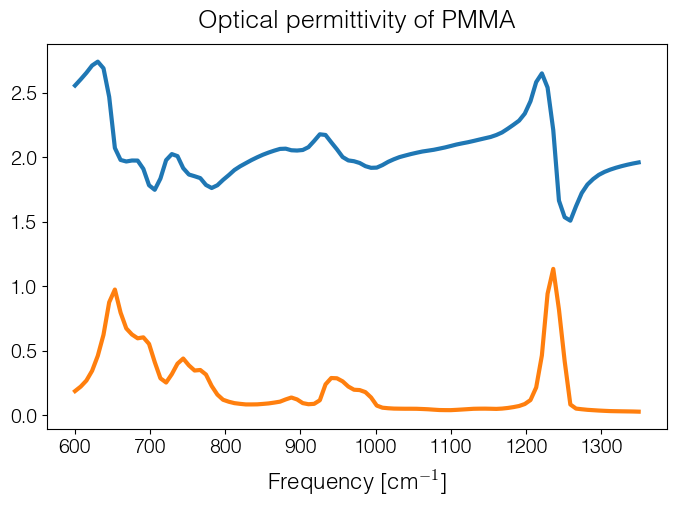

In [16]:
eps_PMMA = M.PMMA.epsilon(freqs_wn)

plt.figure()
plt.plot(freqs_wn,eps_PMMA.real)
plt.plot(freqs_wn,eps_PMMA.imag)
plt.title('Optical permittivity of PMMA')
plt.xlabel(r'Frequency [cm$^{-1}$]')

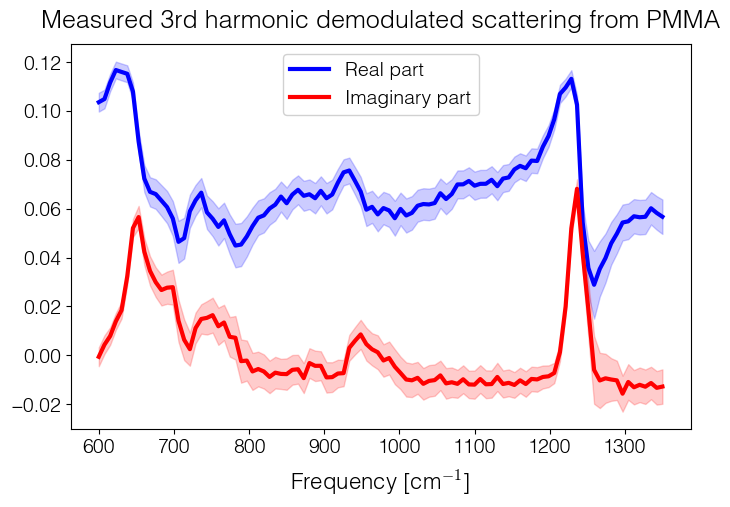

In [17]:
Predictor=Predictor_S3_from_layer

measured_S3_PMMA = np.array([Predictor(qp=None,eps=eps) for eps in eps_PMMA])
measured_S3_PMMA = AWA(measured_S3_PMMA,axes=[freqs_wn],axis_names=['Frequency [cm$^{-1}$]']) # Attach the frequency values as metadata

# Add noise to simulate a genuine experiment
noise_level = 1.5e-3
noise_r = noise_level*np.random.randn(len(measured_S3_PMMA))
noise_i = noise_level*np.random.randn(len(measured_S3_PMMA))
noise = noise_r + 1j*noise_i
measured_S3_PMMA += noise

uncertainty_PMMA = 4e-4 * 1/np.abs(measured_S3_PMMA)
uncertainty_PMMA = AWA(uncertainty_PMMA,axes=[freqs_wn],axis_names=['Frequency [cm$^{-1}$]']) # Attach the frequency values as metadata

toplot = np.abs(measured_S3_PMMA)
plt.fill_between(freqs_wn,toplot-uncertainty_PMMA,toplot+uncertainty_PMMA,color='b',alpha=.2)
plt.plot(freqs_wn,toplot,color='b',label='Real part')

toplot = np.imag(measured_S3_PMMA)
plt.fill_between(freqs_wn,toplot-uncertainty_PMMA,toplot+uncertainty_PMMA,color='r',alpha=.2)
plt.plot(freqs_wn,toplot,color='r',label='Imaginary part')

plt.title('Measured 3rd harmonic demodulated scattering from PMMA')
plt.xlabel(r'Frequency [cm$^{-1}$]')
plt.legend()

## Predict SiO2 spectrum

Text(0.5, 0, 'Frequency [cm$^{-1}$]')

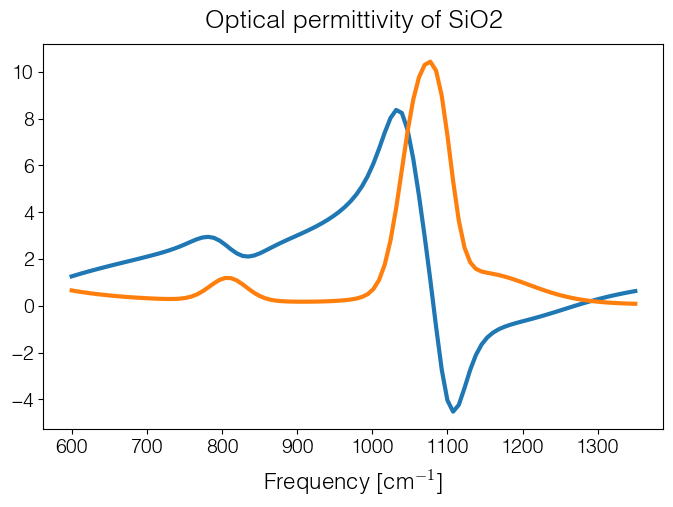

In [18]:
eps_SiO2 = M.SiO2_300nm.epsilon(freqs_wn)

plt.figure()
plt.plot(freqs_wn,eps_SiO2.real)
plt.plot(freqs_wn,eps_SiO2.imag)
plt.title('Optical permittivity of SiO2')
plt.xlabel(r'Frequency [cm$^{-1}$]')

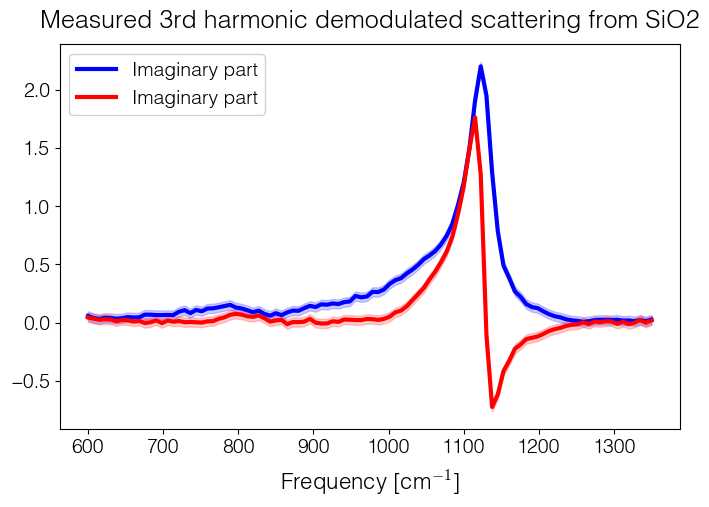

In [19]:
Predictor_S3_from_layer

measured_S3_SiO2 = np.array([Predictor(qp=None,eps=eps) for eps in eps_SiO2])
measured_S3_SiO2 = AWA(measured_S3_SiO2,axes=[freqs_wn],axis_names=['Frequency [cm$^{-1}$]']) # Attach the frequency values as metadata

# Add noise to simulate a genuine experiment
noise_level = 1e-2
noise_r = noise_level*np.random.randn(len(measured_S3_SiO2))
noise_i = noise_level*np.random.randn(len(measured_S3_SiO2))
noise = noise_r + 1j*noise_i
measured_S3_SiO2 += noise

uncertainty_SiO2 = [4*noise_level]*len(freqs_wn)
uncertainty_SiO2 = AWA(uncertainty_SiO2,axes=[freqs_wn],axis_names=['Frequency [cm$^{-1}$]']) # Attach the frequency values as metadata
uncertainty = uncertainty_SiO2

toplot = np.abs(measured_S3_SiO2)
plt.fill_between(freqs_wn,toplot-uncertainty,toplot+uncertainty,color='b',alpha=.2)
plt.plot(freqs_wn,toplot,color='b',label='Imaginary part')

toplot = np.imag(measured_S3_SiO2)
plt.fill_between(freqs_wn,toplot-uncertainty,toplot+uncertainty,color='r',alpha=.2)
plt.plot(freqs_wn,toplot,color='r',label='Imaginary part')

plt.title('Measured 3rd harmonic demodulated scattering from SiO2')
plt.xlabel(r'Frequency [cm$^{-1}$]')
plt.legend()

## Predict spectrum for PMMA film on SiO2

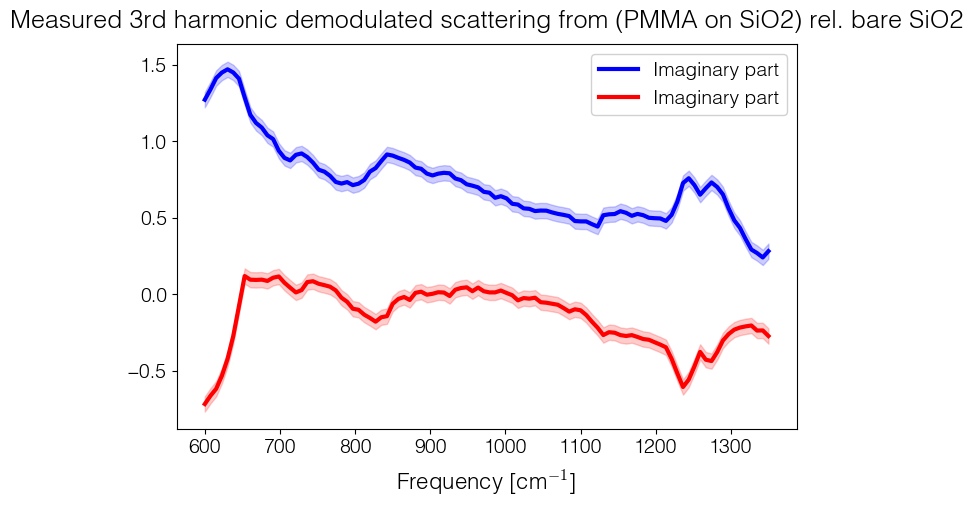

In [20]:
Predictor = Predictor_S3_from_layer

qps_PMMA = [Predictor.eps_to_qp_thin_film(eps) for eps in eps_PMMA]

measured_S3_PMMAonSiO2 = np.array([Predictor(qp=qp,eps=eps) for qp,eps in zip(qps_PMMA,eps_SiO2)])
measured_S3_SiO2_nonoise = np.array([Predictor(qp=None,eps=eps) for qp,eps in zip(qps_PMMA,eps_SiO2)])

measured_S3_PMMAonSiO2 = AWA(measured_S3_PMMAonSiO2,axes=[freqs_wn],axis_names=['Frequency [cm$^{-1}$]']) # Attach the frequency values as metadata

measured_S3_PMMAonSiO2_norm = measured_S3_PMMAonSiO2 / measured_S3_SiO2_nonoise

# Add noise to simulate a genuine experiment
noise_level = 1e-2
noise_r = noise_level*np.random.randn(len(measured_S3_SiO2))
noise_i = noise_level*np.random.randn(len(measured_S3_SiO2))
noise = noise_r + 1j*noise_i
measured_S3_PMMAonSiO2_norm += noise

uncertainty_PMMAonSiO2 = [5e-2]*len(freqs_wn)
uncertainty_PMMAonSiO2 = AWA(uncertainty_PMMAonSiO2,axes=[freqs_wn],axis_names=['Frequency [cm$^{-1}$]']) # Attach the frequency values as metadata
uncertainty = uncertainty_PMMAonSiO2

toplot = np.abs(measured_S3_PMMAonSiO2_norm)
plt.fill_between(freqs_wn,toplot-uncertainty,toplot+uncertainty,color='b',alpha=.2)
plt.plot(freqs_wn,toplot,color='b',label='Imaginary part')

toplot = np.imag(measured_S3_PMMAonSiO2_norm)
plt.fill_between(freqs_wn,toplot-uncertainty,toplot+uncertainty,color='r',alpha=.2)
plt.plot(freqs_wn,toplot,color='r',label='Imaginary part')

plt.title('Measured 3rd harmonic demodulated scattering from (PMMA on SiO2) rel. bare SiO2')
plt.xlabel(r'Frequency [cm$^{-1}$]')
plt.legend()

# Extracting substrate and film properties from their spectra

In [ ]:
#-- None-interactive plotting
%matplotlib inline

## Load or define the known quantities and spectra

In [21]:
# --- We have "measured" spectra:
measured_S3_SiO2; # SiO2 is our substrate, and we have measured its spectrum relative to gold
uncertainty_SiO2; # Uncertainty in the spectrum (or, a spectrum of error bars, or a constant number)
eps_ref = -1e8 # Permittivity of the material we normalized SiO2 against.  If that was gold, a large permittivity describes it.

measured_S3_PMMAonSiO2_norm;  # a PMMA layer sits atop the substrate, and we have measured its spectrum relative to that of the substrate (hence "_norm" suffix)
uncertainty_PMMAonSiO2; # Uncertainty in the spectrum (or, a spectrum of error bars, or a constant number)
PMMA_thickness_nm = 20; # We should know this layer thickness or have measured it.  Optical response of the layer "integrates over its thickness", so we need thickness to infer its polarizability per unit volume (or permittivity).

# --- "Known" parameters of the experiment (here, we only match these to parameters we used to generate spectra!)
a_nm = 20 # Physical dimension of probe radius, in nanometers
A_nm = 80 # Tapping amplitude, in nanometers
gapmin_nm = a_nm/10 # Physical dimension of minimum probe-sample distance, in nanometers

# --- Parameters that only control accuracy / expense of our Predictors
kappa_max=None #20/P.get_a() # Largest value of in-plane momentum (in Probe units) to use for internal momentum quadrature with Fresnel coefficient
Nkappas = 244*2 # Number of momentum quadrature points to use by default
Ngaps = 24 # Number of probe-sample gap nodes to use for computing demodulated scattering

sim_kwargs = dict(amplitude_nm=A_nm,gapmin_nm = gapmin_nm,a_nm=a_nm,Ngaps=Ngaps,Nmodes=Nmodes,harmonic=3)

## Set up a fast Predictor that is capable of predicting measurements from a thin film on a substrate

In [22]:
thin_film_material = M.IsotropicMaterial()
substrate_material = M.IsotropicMaterial()
layered_medium = M.LayeredMediaTM((thin_film_material,PMMA_thickness_nm*1e-7),
                                   exit=substrate_material)
film_layer = layered_medium.get_layers()[0]

# This just so happens to be the same Predictor configuration that we used to forward-simulate "measured" spectra...
# SO we had better be able to use this Predictor to interpret / extract from the same spectra!

Predictor_S3_from_layer= EI.LayeredMediaEncodedEigenfieldsPredictor(EE,
                                                         layered_medium,film_layer,substrate_material,
                                                         qp_ref=None,
                                                         eps_ref=eps_ref,
                                                         **sim_kwargs)


## Set up a material model that can describe our material setup

In [23]:
target_freqs = measured_S3_SiO2.axes[0]
Predictor = Predictor_S3_from_layer

# Set up an "empty" material to hold our fitting results.  We can change all the details later.
PMMA_SiO2_MaterialModel = EI.VariationalMaterial2D(Predictor, target_freqs,
                                                     Nosc_eps=3, amp_eps=0, eps0=1,
                                                     Nosc_qp=3, amp_qp=0,
                                                     eps_vals=None,
                                                     qp_vals=None,
                                                     additional_normalization=None) # Begin with no extra normalization.  Predictor has gold-normalization built-in to its constructor.  We can add SiO2 normalization later.

Recomputing basis of fine oscillators for permittivity...
Recomputing basis of fine oscillators for qp...


## Infer optical constants of SiO2 (substrate)

In [ ]:
#-- None-interactive plotting
%matplotlib inline

### Point-by-point fit for SiO2 permittivity

Elapsed: 0.077483177185058666


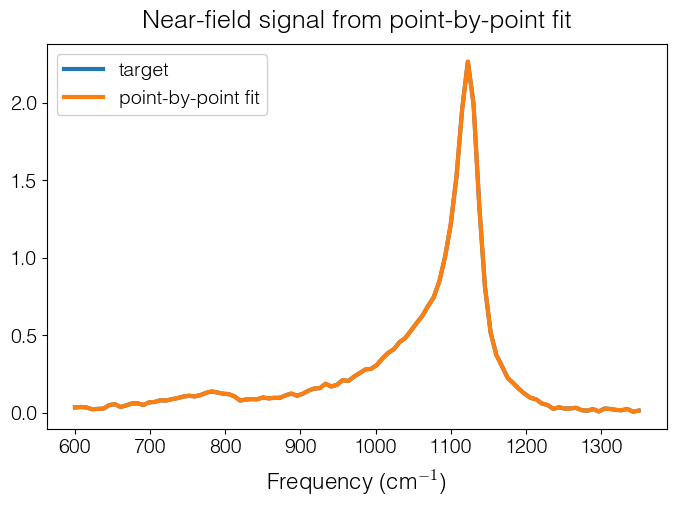

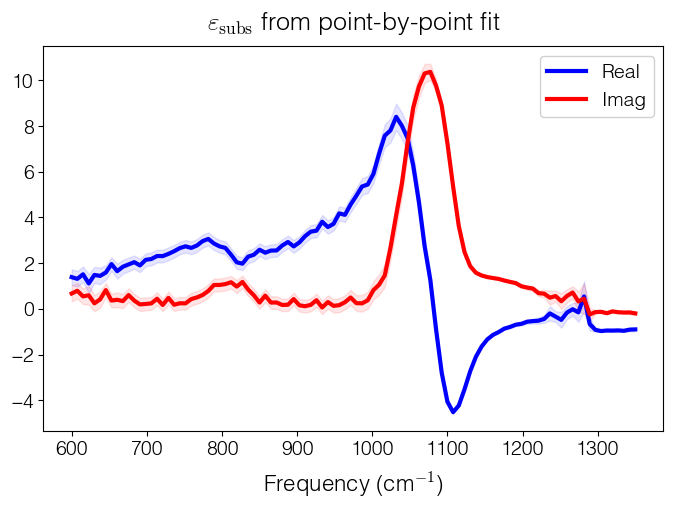

In [66]:
target_freqs = measured_S3_SiO2.axes[0]
S_targets = np.array(measured_S3_SiO2)
S_targets_uncertainty = np.array(uncertainty_SiO2)

Predictor = Predictor_S3_from_layer
eps_guess=2
leastsq_kwargs={}

PbP_fit_SiO2 = EI.Fit_eps_PointByPoint(S_targets, target_freqs,
                                        Predictor, eps_guess,
                                        S_targets_uncertainty=S_targets_uncertainty,
                                        exp=1, plot=True,
                                        reverse=False,
                                        **leastsq_kwargs)

### Obtain a "causal" fit to the point-by-point result

Residual before fitting: 1247.579079641157
Elapsed: 0.195
Residual after fitting: 35.59206064875329
Residual before fitting: 42.21268267571331
Elapsed: 0.191
Residual after fitting: 37.596241088259404
Residual before fitting: 47.97117769340628
Elapsed: 0.236
Residual after fitting: 39.87301520956948
Residual before fitting: 24.718616527869923
Elapsed: 0.197
Residual after fitting: 25.771378551055765
Residual before fitting: 32.402778846120654
Elapsed: 0.222
Residual after fitting: 31.2069869834509
Residual before fitting: 42.011084291306325
Elapsed: 0.152
Residual after fitting: 38.51830465244045
Residual before fitting: 23.075687153386433
Elapsed: 0.179
Residual after fitting: 24.230295653554734
Residual before fitting: 30.778896295374825
Elapsed: 0.197
Residual after fitting: 30.778871508446286
Residual before fitting: 41.73819298158782
Elapsed: 0.219
Residual after fitting: 37.42856837185918


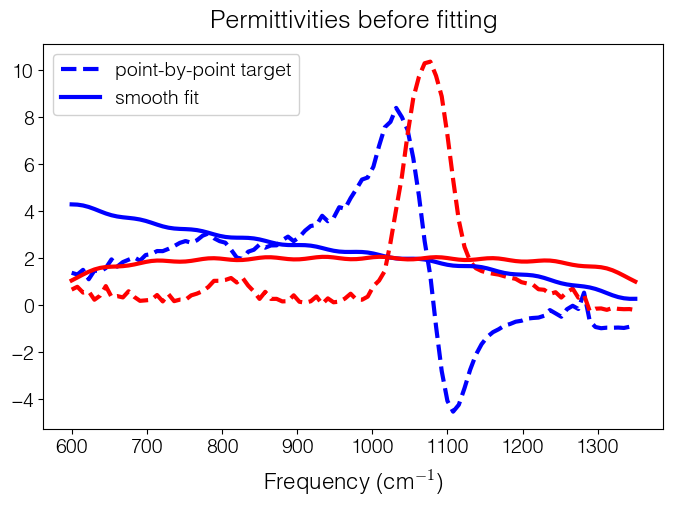

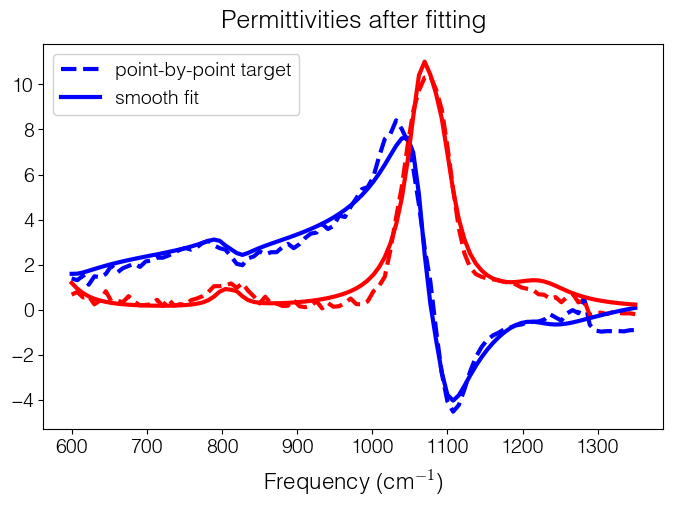

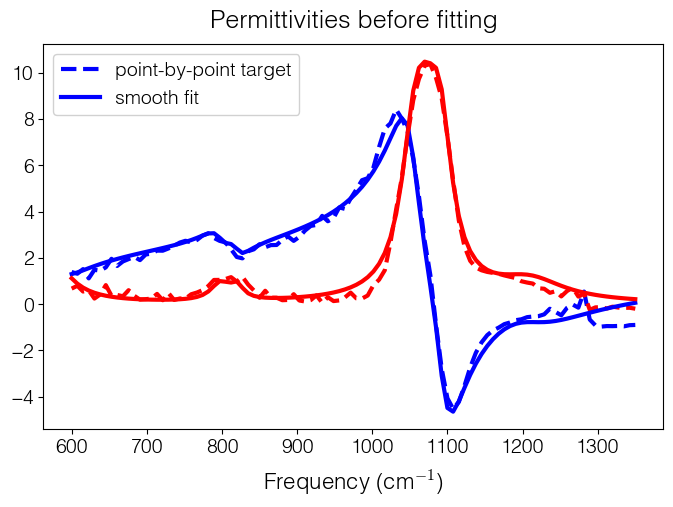

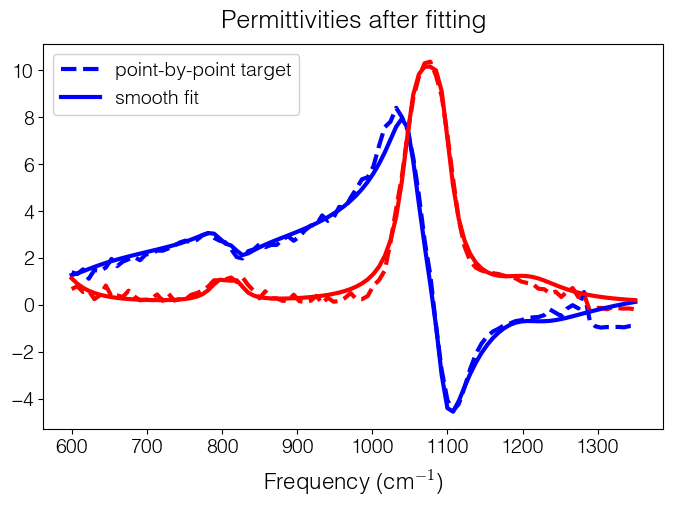

In [67]:
target_freqs = measured_S3_SiO2.axes[0]
eps_target = PbP_fit_SiO2['eps_predicted']
MaterialModel=PMMA_SiO2_MaterialModel
MaterialModel.freqs = target_freqs # Make sure our frequency points are in sync with calculation at targeted points

# Set the parameters of our fit:  10 coarse oscillators atop a background permittivity
MaterialModel.set_coarse_params_eps(Nosc=10, amp=1, eps0=2) # A sufficient number of oscillators is important to obtain a good fit.

leastsq_kwargs = dict(factor=1,maxfev=1000,ftol=1e-12,xtol=1e-12,epsfcn=1e-6) # use whatever helps leastsq do its job
reset_MaterialModel=False

exps=[2,1.5,1]; Nexps=len(exps)
loops=3
for i in range(loops):
    for j,exp in enumerate(exps):
        if (i==loops-1 and j==Nexps-1) or (i==0 and j==0): plot=True # If at beginning or end of our fitting
        else: plot=False
            
        result = EI.Fit_epss_to_oscillators(eps_target, target_freqs,
                                            MaterialModel=MaterialModel, exp=exp,
                                            reset_MaterialModel=False, # Improve upon the fit from previous cycle
                                            plot=plot,
                                            **leastsq_kwargs)

### Refine the SiO2 smooth fit to measured spectrum 

In [69]:
measured_S3 = measured_S3_SiO2
uncertainty = uncertainty_SiO2

MaterialModel=PMMA_SiO2_MaterialModel
MaterialModel.additional_normalization = None # Use (only) the normalization already internal to the Predictor that is attached to the Material Model

#-- Optionally down-sample data, which makes less work for the fitting
downsampling=3 # We may not be able to down-sample much, if we have many oscillators to fit.
S_targets = np.array(measured_S3[::downsampling])
S_targets_uncertainty = np.array(uncertainty[::downsampling])
target_freqs = measured_S3[::downsampling].axes[0]
MaterialModel.freqs = target_freqs # Correspondingly update the frequencies at which we wish to evaluate the model.
print('Fitting to a down-sampled set of %i measurements...'%len(target_freqs))


optimize_coarse = True # It may or may not be that the previous step already provided a good coarse fit, so we can bypass refining the coarse fit
optimize_fine = True # Fine oscillators allow fitting every detail of the spectrum, but can lead to over-fitting when noise is large.
MaterialModel.set_fine_params_eps(Nosc=len(target_freqs)//2, amp=0) # Add (no more than) as many fine oscillators as there are measured frequencies

#----- Run the optimization
#@UPDATE: Choose whatever gives the best result
Nsupercycles=2 # Make this nonzero to actually run cycles of optimization. Improvement is cumulative.
randomization=0 # Some randomization can "nudge" the fitting into a more global optimum
leastsq_kwargs = dict(factor=1,maxfev=200,ftol=1e-8,xtol=1e-8,epsfcn=1e-8) # These parameters are delivered to underlying `leastsq` optimizer; change whichever needed to "nudge" performance

# If the `R=...` value is going down, fitting is doing its job.  The optimization can be intensive.
# Feel free to keyboard interrupt at anytime, the loops will halt with forward progress saved in `MaterialModel`.
for i in range(Nsupercycles):
    print('Supercycle #%i..'%(i+1))

    if optimize_coarse:
        MaterialModel.optimize_eps_coarse(S_targets,S_targets_uncertainty,
                                             exp_start=0.5,exp_stop=2,
                                             Nsubcycles=2,Ncycles=2,
                                              randomization=randomization,
                                             **leastsq_kwargs)

    #--- Disable the fine optimization if we want 2D material properties to vary smoothly with frequency (no over-fitting)

    if optimize_fine:
        MaterialModel.optimize_eps_fine(S_targets,S_targets_uncertainty,
                                         exp_start=0.5,exp_stop=2,
                                         Nsubcycles=2,Ncycles=2,
                                          randomization=randomization,
                                         **leastsq_kwargs)

Fitting to a down-sampled set of 34 measurements...
Recomputing basis of fine oscillators for permittivity...
Supercycle #1..
Optimizing "eps_coarse" with spectral normalization: None
Optimizing "eps_coarse" in cycle #1...
Optimizing "eps_coarse" in subcycle #1, exp=0.50...
R=5.22; time elapsed (s) in cycle: 28.19
Optimizing "eps_coarse" in subcycle #2, exp=2.00...
R=5.01; time elapsed (s) in cycle: 30.62
Optimizing "eps_coarse" in cycle #2...
Optimizing "eps_coarse" in subcycle #1, exp=0.50...
R=4.97; time elapsed (s) in cycle: 32.23
Optimizing "eps_coarse" in subcycle #2, exp=2.00...
R=4.95; time elapsed (s) in cycle: 32.61
Time elapsed (s) for optimization: 123.65547275543213
Optimizing "eps_fine" with spectral normalization: None
Optimizing "eps_fine" in cycle #1...
Optimizing "eps_fine" in subcycle #1, exp=0.50...
R=4.62; time elapsed (s) in cycle: 31.58
Optimizing "eps_fine" in subcycle #2, exp=2.00...
R=4.59; time elapsed (s) in cycle: 31.14
Optimizing "eps_fine" in cycle #2...


Recomputing basis of fine oscillators for permittivity...


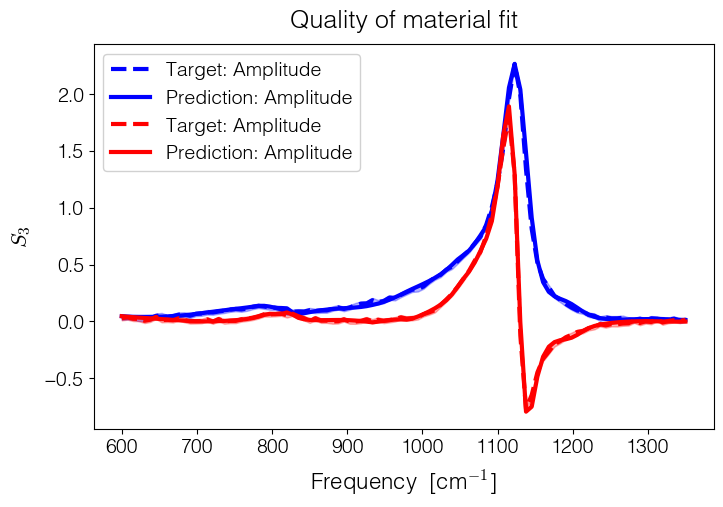

In [70]:
downsampling=1 # Remove that downsampling, let's look at all frequencies
S_targets = np.array(measured_S3_SiO2[::downsampling])
S_targets_uncertainty = np.array(uncertainty_SiO2[::downsampling])
target_freqs = measured_S3_SiO2[::downsampling].axes[0]

MaterialModel.freqs = target_freqs

#---- Plot the prediction
S_pred = MaterialModel.predict(qps_enabled=False)

plt.figure()
plt.title('Quality of material fit')
#plt.plot(target_fs,np.abs(target_spectra[sio2]),ls='--',color='b',label='Target for substrate')
#plt.plot(target_fs,np.abs(S_SiO2_pred),ls='-',color='b',label='Prediction for substrate')
toplot=np.abs(S_targets)
plt.plot(target_freqs,toplot,ls='--',color='b',label='Target: Amplitude')
plt.fill_between(target_freqs,toplot-S_targets_uncertainty/2,toplot+S_targets_uncertainty/2,color='b',alpha=.3)
plt.plot(target_freqs,np.abs(S_pred),ls='-',color='b',label='Prediction: Amplitude')

toplot=np.imag(S_targets)
plt.plot(target_freqs,toplot,ls='--',color='r',label='Target: Amplitude')
plt.fill_between(target_freqs,toplot-S_targets_uncertainty/2,toplot+S_targets_uncertainty/2,color='r',alpha=.3)
plt.plot(target_freqs,np.imag(S_pred),ls='-',color='r',label='Prediction: Amplitude')
plt.ylabel(r'$S_3$')
plt.xlabel(r'Frequency  [cm$^{-1}$]')
plt.legend()

### Finally, compare the extracted permittivity against ground truth

Recomputing basis of fine oscillators for qp...


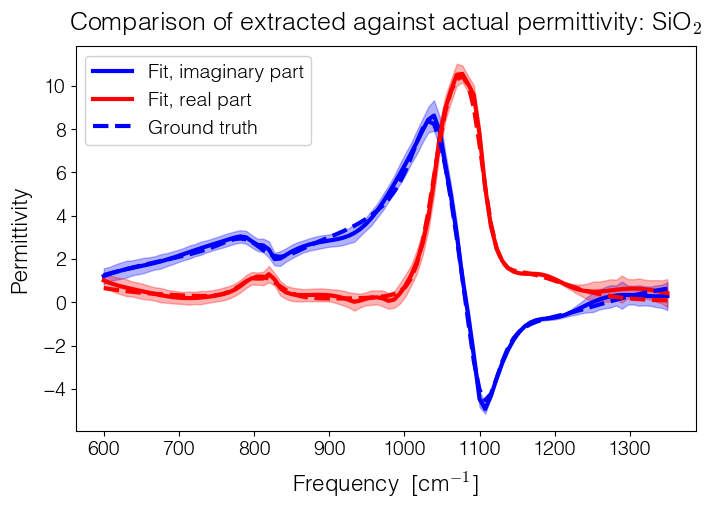

In [71]:
#---- Estimate the error / uncertainty in the extracted permittivity

pred_dev = np.abs(S_pred-S_targets) # Deviation of prediction from target, so the fit is definitely uncertain here
error_vs_meas = np.sqrt(pred_dev**2+S_targets_uncertainty**2) 
deps,dqp = MaterialModel.estimate_error(error_vs_meas,offset=.01) # Converts an error in output of model to corresponding error in input (permittivity)

eps_pred = MaterialModel.get_epss()
eps_freqs = MaterialModel.freqs


# --- Plot inferred permittivity in comparison to ground truth 

toplot=eps_pred.real
plt.plot(eps_freqs, toplot,color='b',label='Fit, imaginary part')
plt.fill_between(eps_freqs,toplot-deps/2,toplot+deps/2,color='b',alpha=.3)

toplot=eps_pred.imag
plt.plot(eps_freqs, toplot,color='r',label='Fit, real part')
plt.fill_between(eps_freqs,toplot-deps/2,toplot+deps/2,color='r',alpha=.3)

plt.plot(freqs_wn,eps_SiO2.real,ls='--',color='b',label='Ground truth')
plt.plot(freqs_wn,eps_SiO2.imag,ls='--',color='r')

plt.xlabel(r'Frequency  [cm$^{-1}$]')
plt.ylabel('Permittivity')
plt.title(r'Comparison of extracted against actual permittivity: SiO$_2$')
plt.legend()

## Infer optical constants of PMMA (thin film on SiO2)

In [ ]:
#-- None-interactive plotting
%matplotlib inline

In [72]:
# We believe we now know the permittivity of the substrate.  Use that to inform forthcoming inferences about properties of PMMA layer.
eps_subs = MaterialModel.get_epss()

### Point-by-point fit to PMMA properties

Elapsed: 33.9880588054657.367


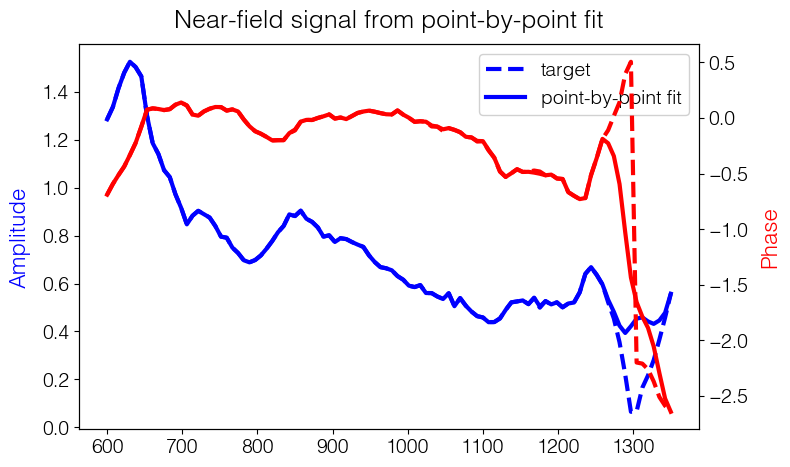

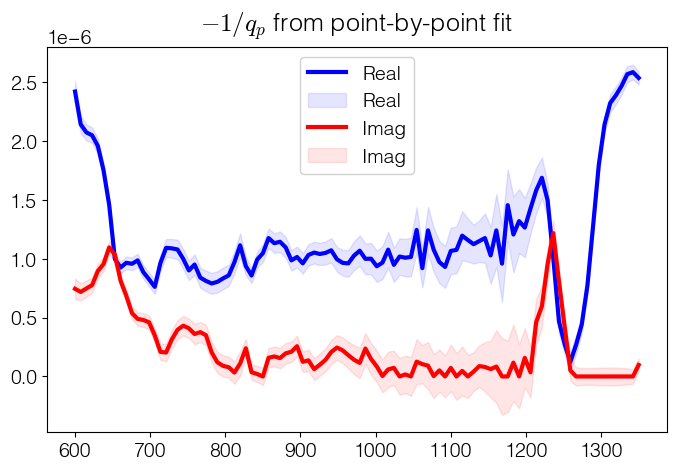

In [103]:
target_freqs = measured_S3_PMMAonSiO2_norm.axes[0]
S_targets = np.array(measured_S3_PMMAonSiO2_norm)
S_targets_uncertainty = np.array(uncertainty_PMMAonSiO2)

Predictor = Predictor_S3_from_layer
qp_guess=-1/P.get_a() # Should be in units of (and of order of) the inverse probe radius
leastsq_kwargs={}

PbP_fit_PMMA = EI.Fit_qp_PointByPoint(S_targets, target_freqs,
                                       Predictor, eps_subs, qp_guess,
                                       S_targets_uncertainty=S_targets_uncertainty, exp=0.5, plot=True,
                                        reverse=False,
                                       **leastsq_kwargs)

### Obtain a "causal" fit to the point-by-point result

Residual before fitting: 1.3856198978549422e-09
Elapsed: 0.256
Residual after fitting: 2.113889293849179e-11
Residual before fitting: 2.5619508541669717e-08
Elapsed: 0.440
Residual after fitting: 2.2534317519349848e-08
Residual before fitting: 3.1603144799081365e-05
Elapsed: 0.277
Residual after fitting: 2.466577825407089e-05
Residual before fitting: 1.4611623819859972e-11
Elapsed: 0.256
Residual after fitting: 1.9919442972603978e-11
Residual before fitting: 2.6132367118137412e-08
Elapsed: 0.009
Residual after fitting: 2.6132367118137412e-08
Residual before fitting: 3.5921877348617825e-05
Elapsed: 0.009
Residual after fitting: 3.5921877348617825e-05
Residual before fitting: 1.9919442972603978e-11
Elapsed: 0.008
Residual after fitting: 1.9919442972603978e-11
Residual before fitting: 2.6132367118137412e-08
Elapsed: 0.008
Residual after fitting: 2.6132367118137412e-08
Residual before fitting: 3.5921877348617825e-05
Elapsed: 0.009
Residual after fitting: 3.5921877348617825e-05


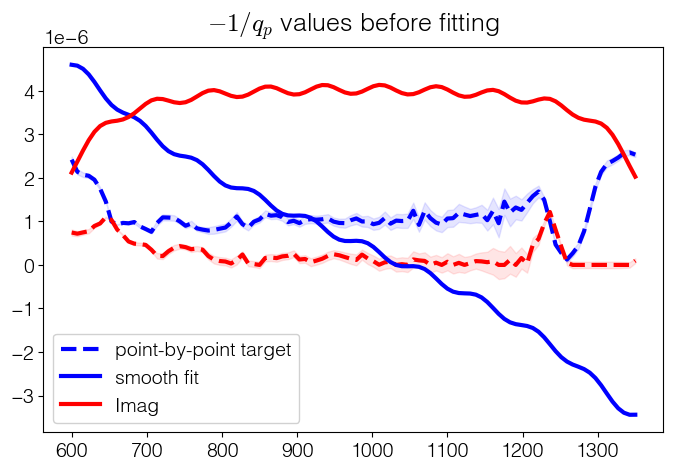

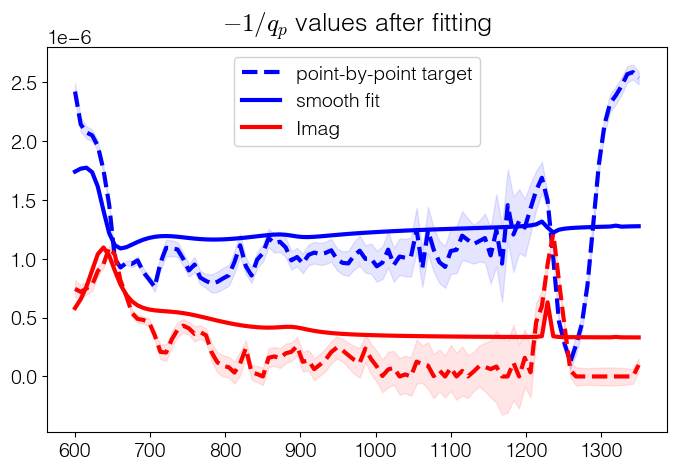

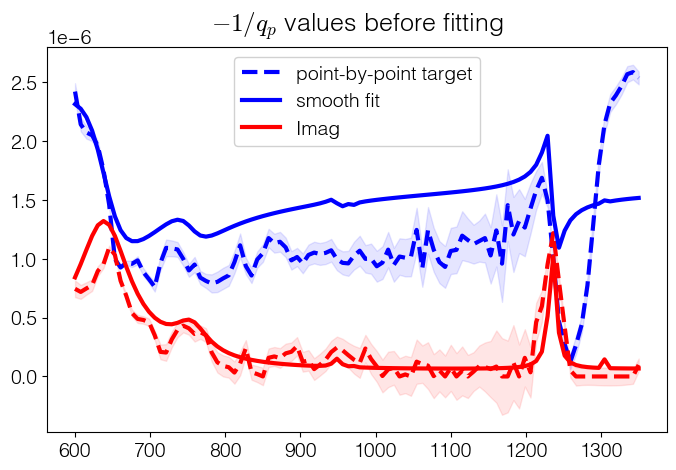

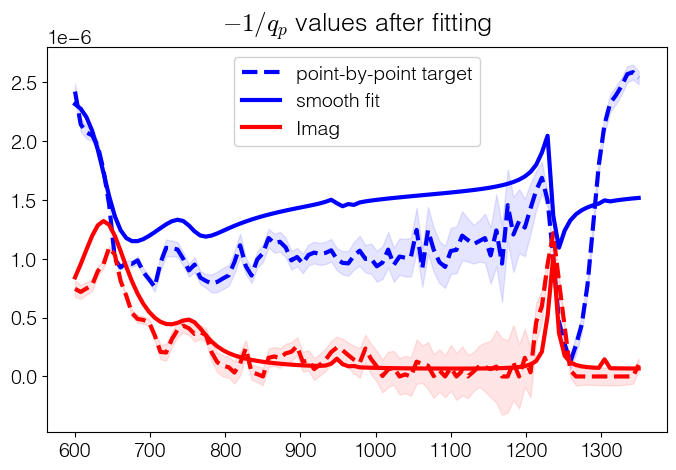

In [104]:
target_freqs = measured_S3_PMMAonSiO2_norm.axes[0]
qp_target = PbP_fit_PMMA['qp_predicted']
qpinv_target_uncertainties = PbP_fit_PMMA['Delta_qps']/PbP_fit_PMMA['qp_predicted']**2
MaterialModel.freqs = target_freqs # Make sure our frequency points are in sync with calculation at targeted points

# Set the parameters of our fit:  15 coarse oscillators atop a background permittivity
MaterialModel.set_coarse_params_qp(Nosc=10, amp=1/qp_guess, eps0=0) # A sufficient number of oscillators is important to obtain a good fit.

leastsq_kwargs = dict(factor=1,maxfev=1000,ftol=1e-12,xtol=1e-12,epsfcn=1e-6) # use whatever helps leastsq do its job
reset_MaterialModel=False

exps=[2,1.5,1]; Nexps=len(exps)
loops=3
for i in range(loops):
    for j,exp in enumerate(exps):
        if (i==loops-1 and j==Nexps-1) or (i==0 and j==0): plot=True # If at beginning or end of our fitting
        else: plot=False
            
        result = EI.Fit_qps_to_oscillators(qp_target, target_freqs,
                                               MaterialModel=MaterialModel,exp=exp,
                                               qpinv_target_uncertainties=qpinv_target_uncertainties,
                                               reset_MaterialModel=False,
                                            plot=plot,
                                               **leastsq_kwargs)

### Refine the PMMA smooth fit to measured spectrum

In [105]:
#-- Select our material model
MaterialModel=PMMA_SiO2_MaterialModel
# Enable the following to discard the point-by-point fit, and globally refine to measured spectrum only
MaterialModel.set_coarse_params_qp(Nosc=10, amp=1/qp_guess, eps0=0) # A sufficient number of oscillators is important to obtain a good fit.

#-- Optionally down-sample data, which makes less work for the fitting
downsampling=2 # We may not be able to down-sample much, if we have many oscillators to fit.
S_targets = np.array(measured_S3_PMMAonSiO2_norm[::downsampling])
S_targets_uncertainty = np.array(uncertainty_PMMAonSiO2[::downsampling])
target_freqs = measured_S3_PMMAonSiO2_norm[::downsampling].axes[0]
MaterialModel.freqs = target_freqs # Correspondingly update the frequencies at which we wish to evaluate the model.
print('Fitting to a down-sampled set of %i measurements...'%len(target_freqs))

#-- Make our Material Model to predict spectra relative to substrate
# `MaterialModel` needs to know that our measurements were normalized to the substrate, and we can predict that one since we've fit it well.
MaterialModel.additional_normalization = None
S_prediction_substrate = MaterialModel.predict(qps_enabled=False)
MaterialModel.additional_normalization = S_prediction_substrate # the keyword implies we are "turning off" the top layer, leaving only the substrate


optimize_fine = False # Probably best to keep fine oscillators disabled for 2D material, otherwise we're likely to over-fit the noise
MaterialModel.set_fine_params_qp(Nosc=len(target_freqs)//2, amp=0) # Add as many oscillators (or fewer) as there are measured frequencies

#----- Run the optimization
#@UPDATE: Choose whatever gives the best result
Nsupercycles=2 # Make this nonzero to actually run cycles of optimization. Improvement is cumulative.
randomization=0 # Some randomization can "nudge" the fitting into a more global optimum
leastsq_kwargs = dict(factor=1,maxfev=100,ftol=1e-8,xtol=1e-8,epsfcn=1e-6) # These parameters are delivered to underlying `leastsq` optimizer; change whichever needed to "nudge" performance

for i in range(Nsupercycles):
    print('Supercycle #%i..'%(i+1))
    
    MaterialModel.optimize_qp_coarse(S_targets,S_targets_uncertainty,
                                         exp_start=0.5,exp_stop=2,
                                         Nsubcycles=2,Ncycles=2,
                                          randomization=randomization,
                                         **leastsq_kwargs)

    #--- Disable the fine optimization if we want 2D material properties to vary smoothly with frequency (no over-fitting)

    if optimize_fine:
        MaterialModel.optimize_qp_fine(S_targets,S_targets_uncertainty,
                                         exp_start=0.5,exp_stop=2,
                                         Nsubcycles=2,Ncycles=2,
                                          randomization=randomization,
                                         **leastsq_kwargs)

Fitting to a down-sampled set of 50 measurements...
Recomputing basis of fine oscillators for permittivity...
Recomputing basis of fine oscillators for qp...
Supercycle #1..
Optimizing "qp_coarse" with spectral normalization: externally supplied spectrum (static)
Optimizing "qp_coarse" in cycle #1...
Optimizing "qp_coarse" in subcycle #1, exp=0.50...
R=48.11; time elapsed (s) in cycle: 21.99
Optimizing "qp_coarse" in subcycle #2, exp=2.00...
R=21.79; time elapsed (s) in cycle: 22.11
Optimizing "qp_coarse" in cycle #2...
Optimizing "qp_coarse" in subcycle #1, exp=0.50...
R=12.90; time elapsed (s) in cycle: 24.30
Optimizing "qp_coarse" in subcycle #2, exp=2.00...
R=11.25; time elapsed (s) in cycle: 23.90
Time elapsed (s) for optimization: 92.30865812301636
Supercycle #2..
Optimizing "qp_coarse" with spectral normalization: externally supplied spectrum (static)
Optimizing "qp_coarse" in cycle #1...
Optimizing "qp_coarse" in subcycle #1, exp=0.50...
R=11.11; time elapsed (s) in cycle: 22.4

Recomputing basis of fine oscillators for permittivity...
Recomputing basis of fine oscillators for qp...


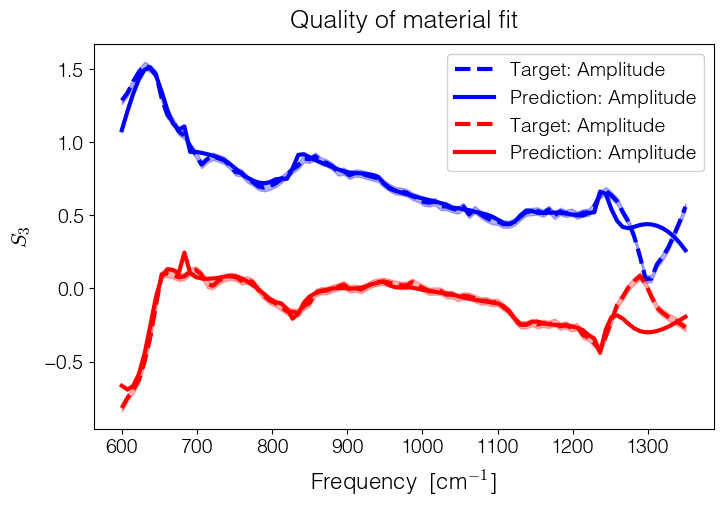

In [106]:
downsampling=1 # Remove that downsampling, let's look at all frequencies
S_targets = np.array(measured_S3_PMMAonSiO2_norm[::downsampling])
S_targets_uncertainty = np.array(uncertainty_PMMAonSiO2[::downsampling])
target_freqs = measured_S3_PMMAonSiO2_norm[::downsampling].axes[0]
MaterialModel.freqs = target_freqs # Correspondingly update the frequencies at which we wish to evaluate the model.
MaterialModel.additional_normalization = None

# `MaterialModel` needs to know that our measurements were normalized to the substrate, and we can predict that one since we've fit it well.
MaterialModel.additional_normalization = MaterialModel.predict(qps_enabled=False) # the keyword implies we are "turning off" the top layer, leaving only the substrate

#---- Plot the prediction
S_pred = MaterialModel.predict(qps_enabled=True)

plt.figure()
plt.title('Quality of material fit')
#plt.plot(target_fs,np.abs(target_spectra[sio2]),ls='--',color='b',label='Target for substrate')
#plt.plot(target_fs,np.abs(S_SiO2_pred),ls='-',color='b',label='Prediction for substrate')
toplot=np.abs(S_targets)
plt.plot(target_freqs,toplot,ls='--',color='b',label='Target: Amplitude')
plt.fill_between(target_freqs,toplot-S_targets_uncertainty/2,toplot+S_targets_uncertainty/2,color='b',alpha=.3)
plt.plot(target_freqs,np.abs(S_pred),ls='-',color='b',label='Prediction: Amplitude')

toplot=np.imag(S_targets)
plt.plot(target_freqs,toplot,ls='--',color='r',label='Target: Amplitude')
plt.fill_between(target_freqs,toplot-S_targets_uncertainty/2,toplot+S_targets_uncertainty/2,color='r',alpha=.3)
plt.plot(target_freqs,np.imag(S_pred),ls='-',color='r',label='Prediction: Amplitude')
plt.ylabel(r'$S_3$')
plt.xlabel(r'Frequency  [cm$^{-1}$]')
plt.legend()

### Finally, compare the extracted PMMA permittivity against ground truth

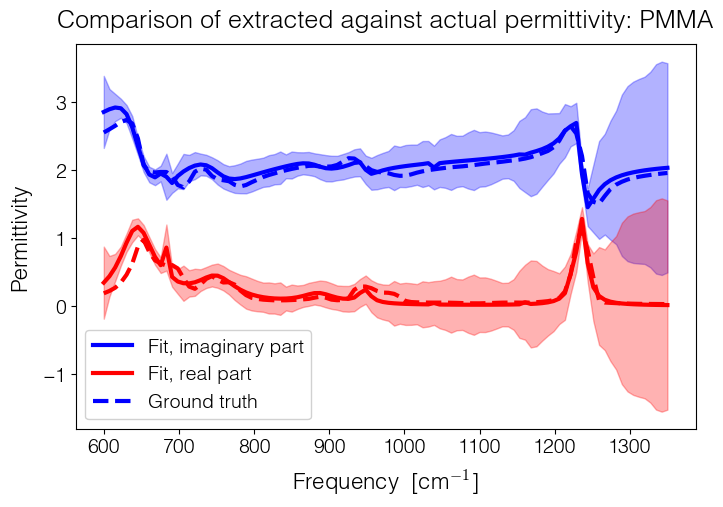

In [107]:
#---- Estimate the error / uncertainty in the extracted permittivity

pred_dev = np.abs(S_pred-S_targets) # Deviation of prediction from target, so the fit is definitely uncertain here
error_vs_meas = np.sqrt(pred_dev**2+S_targets_uncertainty**2) 
deps,dqp = MaterialModel.estimate_error(error_vs_meas,offset=.01) # Converts an error in output of model to corresponding error in input (permittivity)

# --- Convert `qp` of the film to a genuine film permittivity
# Material model knows the values of `qp` that well describe the thin film.
# Meanwhile, predictor knows the relationship between `qp` and permittivity of the film, because it knows the film thickness
qps_pred = MaterialModel.get_qps()
freqs = MaterialModel.freqs
eps_film_pred = Predictor_S3_from_layer.qp_to_eps_thin_film(qps_pred)
deps = np.abs(eps_film_pred * dqp/qps_pred) # This is an error propagation

# --- Plot inferred permittivity in comparison to ground truth 

toplot=eps_film_pred.real
plt.plot(freqs, toplot,color='b',label='Fit, imaginary part')
plt.fill_between(freqs,toplot-deps/2,toplot+deps/2,color='b',alpha=.3)

toplot=eps_film_pred.imag
plt.plot(freqs, toplot,color='r',label='Fit, real part')
plt.fill_between(freqs,toplot-deps/2,toplot+deps/2,color='r',alpha=.3)

plt.plot(freqs,eps_PMMA.real,ls='--',color='b',label='Ground truth')
plt.plot(freqs,eps_PMMA.imag,ls='--',color='r')

plt.xlabel(r'Frequency  [cm$^{-1}$]')
plt.ylabel('Permittivity')
plt.title(r'Comparison of extracted against actual permittivity: PMMA')
plt.legend()

# Extract permittivity from bulk polymer spectrum

## Load or define the known quantities and spectra

In [81]:
# --- We have "measured" spectra:
measured_S3_PMMA; # PMMA spectrum relative to gold
uncertainty_PMMA; # Uncertainty in the spectrum (or, a spectrum of error bars, or a constant number)
eps_ref = -1e8 # Permittivity of the material we normalized SiO2 against.  If that was gold, a large permittivity describes it.

# --- "Known" parameters of the experiment (here, we only match these to parameters we used to generate spectra!)
a_nm = 20 # Physical dimension of probe radius, in nanometers
A_nm = 80 # Tapping amplitude, in nanometers
gapmin_nm = a_nm/10 # Physical dimension of minimum probe-sample distance, in nanometers

# --- Parameters that only control accuracy / expense of our Predictors
kappa_max=None #20/P.get_a() # Largest value of in-plane momentum (in Probe units) to use for internal momentum quadrature with Fresnel coefficient
Nkappas = 244*2 # Number of momentum quadrature points to use by default
Ngaps = 24 # Number of probe-sample gap nodesto use for computing demodulated scattering

sim_kwargs = dict(amplitude_nm=A_nm,gapmin_nm = gapmin_nm,a_nm=a_nm,Ngaps=Ngaps,Nmodes=Nmodes,harmonic=3)

## Set up an *extremeley fast* Predictor that is capable of predicting measurements from a bulk medium

In [82]:
# Awkwardly, the setup for `InvertibleEigenfieldsPredictor` is not (yet) uniform with other Predictors.. (2026.08.10)
#   So we have we have to change the units of these parameters first.
sim_kwargs2 = {}
conversion = P.get_a()/sim_kwargs['a_nm']
sim_kwargs2['zmin']=sim_kwargs['gapmin_nm']*conversion
sim_kwargs2['A']=sim_kwargs['amplitude_nm']*conversion
sim_kwargs2['Ngaps']=sim_kwargs['Ngaps']
sim_kwargs2['harmonic']=sim_kwargs['harmonic']

Predictor_S3_from_bulk = EI.InvertibleEigenfieldsPredictor(invertible_eigenfields=IE,
                                                           eps_ref = eps_ref, **sim_kwargs2)

## Infer optical constants for PMMA with the most robust protocol

### Point-by-point fit for PMMA permittivity

Elapsed: 0.005628824234008789


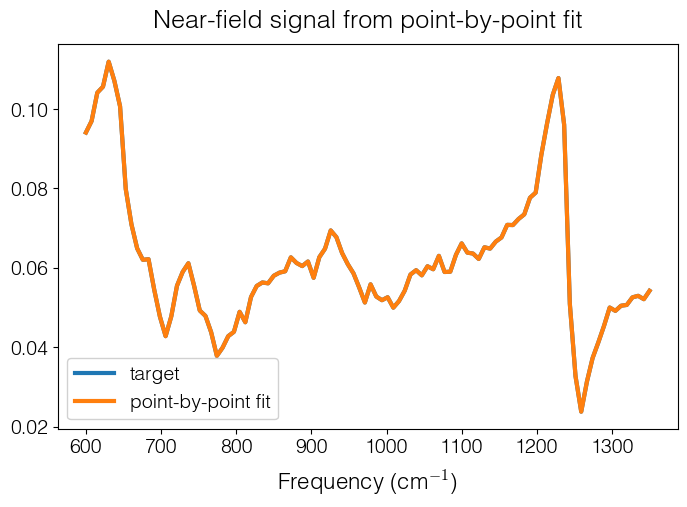

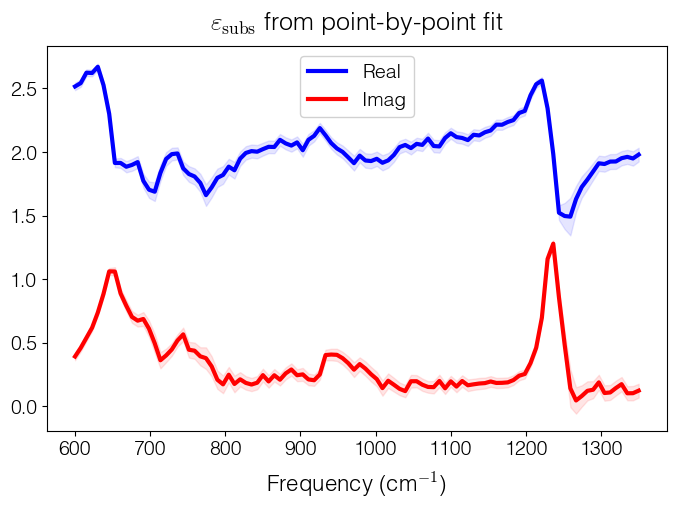

In [83]:
target_freqs = measured_S3_PMMA.axes[0]
S_targets = np.array(measured_S3_PMMA)
S_targets_uncertainty = np.array(uncertainty_PMMA)

Predictor = Predictor_S3_from_bulk
eps_guess=1 # The initial guess is important.  A polymer will have positive permittivity, unlike a metal.
leastsq_kwargs = {}#dict(factor=1,maxfev=100,ftol=1e-8,xtol=1e-8,epsfcn=1e-12) 

PbP_fit_PMMA = EI.Fit_eps_PointByPoint(S_targets, target_freqs,
                                        Predictor, eps_guess,
                                        S_targets_uncertainty=S_targets_uncertainty,
                                        exp=2, plot=True,
                                        reverse=False,
                                        **leastsq_kwargs)

### Obtain a "causal" fit to the point-by-point result

In [84]:
target_freqs = measured_S3_PMMA.axes[0]
Predictor = Predictor_S3_from_bulk

# Set up an "empty" material to hold our fitting results.  We can change all the details later.
PMMA_MaterialModel = EI.VariationalMaterial2D(Predictor, target_freqs,
                                             Nosc_eps=3, amp_eps=0, eps0=1,
                                             Nosc_qp=3, amp_qp=0,
                                             eps_vals=None,
                                             qp_vals=None,
                                             additional_normalization=None) # Begin with no extra normalization.  Predictor has gold-normalization built-in to its constructor.  We can add SiO2 normalization later.

Recomputing basis of fine oscillators for permittivity...
Recomputing basis of fine oscillators for qp...


Residual before fitting: 356.96612364924005
Elapsed: 0.132
Residual after fitting: 0.8608713321582001
Residual before fitting: 2.5835816288123468
Elapsed: 0.217
Residual after fitting: 2.2429088651896176
Residual before fitting: 7.336547246577716
Elapsed: 0.210
Residual after fitting: 6.443851486608792
Residual before fitting: 0.6579654586722695
Elapsed: 0.207
Residual after fitting: 0.732512010731999
Residual before fitting: 2.2980353115386767
Elapsed: 0.210
Residual after fitting: 1.7447464457636925
Residual before fitting: 6.22094626508513
Elapsed: 0.210
Residual after fitting: 5.222265571818648
Residual before fitting: 0.41162870934344026
Elapsed: 0.208
Residual after fitting: 0.46233557196031666
Residual before fitting: 1.6173933942677121
Elapsed: 0.216
Residual after fitting: 1.461215412573939
Residual before fitting: 5.527399896327769
Elapsed: 0.210
Residual after fitting: 5.089622124405251


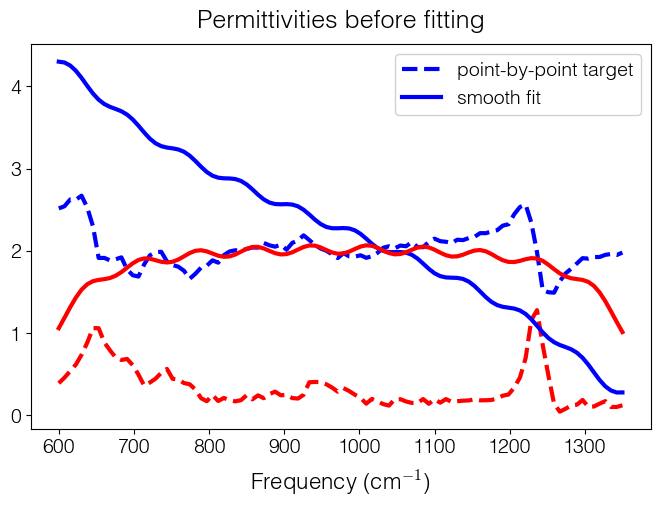

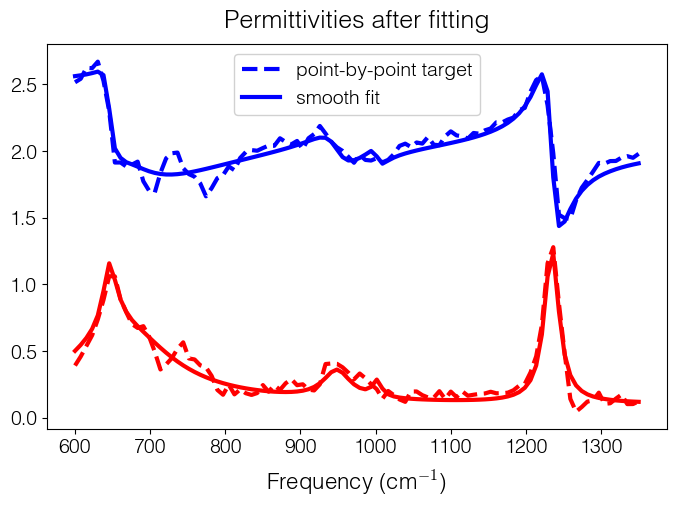

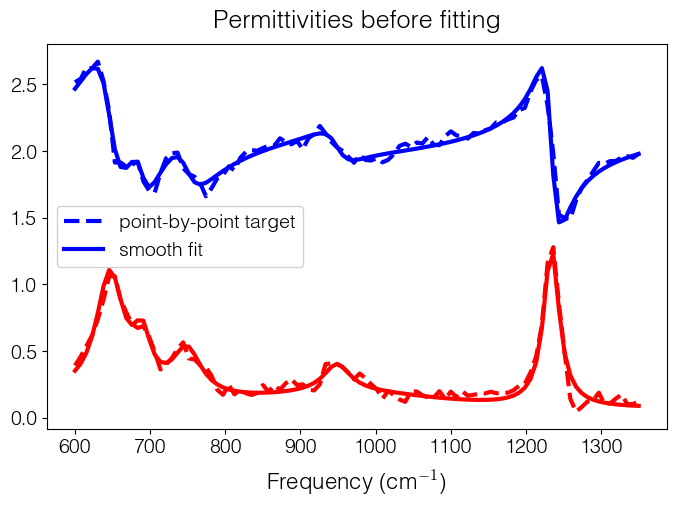

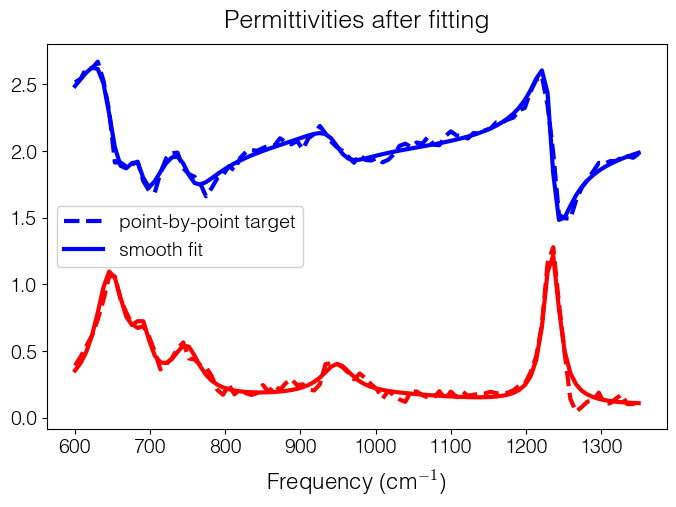

In [85]:
target_freqs = measured_S3_PMMA.axes[0]
eps_target = PbP_fit_PMMA['eps_predicted']
MaterialModel=PMMA_MaterialModel
MaterialModel.freqs = target_freqs # Make sure our frequency points are in sync with calculation at targeted points

# Set the parameters of our fit:  10 coarse oscillators atop a background permittivity
MaterialModel.set_coarse_params_eps(Nosc=10, amp=1, eps0=2) # A sufficient number of oscillators is important to obtain a good fit.

leastsq_kwargs = dict(factor=1,maxfev=1000,ftol=1e-12,xtol=1e-12,epsfcn=1e-6) # use whatever helps leastsq do its job
reset_MaterialModel=False

exps=[2,1.5,1]; Nexps=len(exps)
loops=3
for i in range(loops):
    for j,exp in enumerate(exps):
        if (i==loops-1 and j==Nexps-1) or (i==0 and j==0): plot=True # If at beginning or end of our fitting
        else: plot=False
            
        result = EI.Fit_epss_to_oscillators(eps_target, target_freqs,
                                            MaterialModel=MaterialModel, exp=exp,
                                            reset_MaterialModel=False, # Improve upon the fit from previous cycle
                                            plot=plot,
                                            **leastsq_kwargs)

### Refine the PMMA smooth fit to measured spectrum

In [86]:
measured_S3 = measured_S3_PMMA
uncertainty = uncertainty_PMMA

MaterialModel=PMMA_MaterialModel
MaterialModel.additional_normalization = None


#-- Optionally down-sample data, which makes less work for the fitting
downsampling=3 # We may not be able to down-sample much, if we have many oscillators to fit.
S_targets = np.array(measured_S3[::downsampling])
S_targets_uncertainty = np.array(uncertainty[::downsampling])
target_freqs = measured_S3[::downsampling].axes[0]
MaterialModel.freqs = target_freqs # Correspondingly update the frequencies at which we wish to evaluate the model.
print('Fitting to a down-sampled set of %i measurements...'%len(target_freqs))


optimize_coarse = True # It may or may not be that the previous step already provided a good coarse fit, so we can bypass refining the coarse fit
optimize_fine = True # Fine oscillators allow fitting every detail of the spectrum, but can lead to over-fitting when noise is large.
MaterialModel.set_fine_params_eps(Nosc=len(target_freqs)//2, amp=0) # Add (no more than) as many fine oscillators as there are measured frequencies

#----- Run the optimization
#@UPDATE: Choose whatever gives the best result
Nsupercycles=4 # Make this nonzero to actually run cycles of optimization, otherwise just plot the prediction
randomization=0 # Some randomization can "nudge" the fitting into a more global optimum
leastsq_kwargs = dict(factor=1,maxfev=100,ftol=1e-8,xtol=1e-8,epsfcn=1e-8) # These parameters are delivered to underlying `leastsq` optimizer; change whichever needed to "nudge" performance

# Feel free to keyboard interrupt at anytime, the loops will halt with forward progress saved in `MaterialModel`.
for i in range(Nsupercycles):
    print('Supercycle #%i..'%(i+1))

    if optimize_coarse:
        MaterialModel.optimize_eps_coarse(S_targets,S_targets_uncertainty,
                                             exp_start=0.5,exp_stop=2,
                                             Nsubcycles=2,Ncycles=2,
                                              randomization=randomization,
                                             **leastsq_kwargs)

    #--- Disable the fine optimization if we want 2D material properties to vary smoothly with frequency (no over-fitting)

    if optimize_fine:
        MaterialModel.optimize_eps_fine(S_targets,S_targets_uncertainty,
                                         exp_start=0.5,exp_stop=2,
                                         Nsubcycles=2,Ncycles=2,
                                          randomization=randomization,
                                         **leastsq_kwargs)

Fitting to a down-sampled set of 34 measurements...
Recomputing basis of fine oscillators for permittivity...
Supercycle #1..
Recomputing basis of fine oscillators for qp...
Optimizing "eps_coarse" with spectral normalization: None
Optimizing "eps_coarse" in cycle #1...
Optimizing "eps_coarse" in subcycle #1, exp=0.50...
R=1.84; time elapsed (s) in cycle: 0.06
Optimizing "eps_coarse" in subcycle #2, exp=2.00...
R=1.74; time elapsed (s) in cycle: 0.06
Optimizing "eps_coarse" in cycle #2...
Optimizing "eps_coarse" in subcycle #1, exp=0.50...
R=1.66; time elapsed (s) in cycle: 0.07
Optimizing "eps_coarse" in subcycle #2, exp=2.00...
R=1.64; time elapsed (s) in cycle: 0.08
Time elapsed (s) for optimization: 0.27466893196105957
Optimizing "eps_fine" with spectral normalization: None
Optimizing "eps_fine" in cycle #1...
Optimizing "eps_fine" in subcycle #1, exp=0.50...
R=1.59; time elapsed (s) in cycle: 0.08
Optimizing "eps_fine" in subcycle #2, exp=2.00...
R=1.58; time elapsed (s) in cycle:

Fitting to a down-sampled set of 100 measurements...
Recomputing basis of fine oscillators for permittivity...
Recomputing basis of fine oscillators for qp...


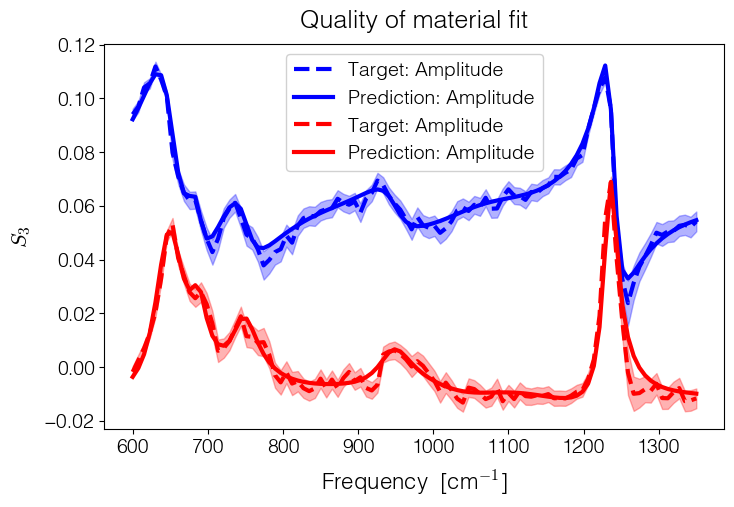

In [87]:
measured_S3 = measured_S3_PMMA
uncertainty = uncertainty_PMMA
MaterialModel=PMMA_MaterialModel

#-- Optionally down-sample data, which makes less work for the fitting
downsampling=1 # We may not be able to down-sample much, if we have many oscillators to fit.
S_targets = np.array(measured_S3[::downsampling])
S_targets_uncertainty = np.array(uncertainty[::downsampling])
target_freqs = measured_S3[::downsampling].axes[0]
MaterialModel.freqs = target_freqs # Correspondingly update the frequencies at which we wish to evaluate the model.
print('Fitting to a down-sampled set of %i measurements...'%len(target_freqs))

#---- Plot the prediction
S_pred = MaterialModel.predict(qps_enabled=True)

plt.figure()
plt.title('Quality of material fit')
#plt.plot(target_fs,np.abs(target_spectra[sio2]),ls='--',color='b',label='Target for substrate')
#plt.plot(target_fs,np.abs(S_SiO2_pred),ls='-',color='b',label='Prediction for substrate')
toplot=np.abs(S_targets)
plt.plot(target_freqs,toplot,ls='--',color='b',label='Target: Amplitude')
plt.fill_between(target_freqs,toplot-S_targets_uncertainty/2,toplot+S_targets_uncertainty/2,color='b',alpha=.3)
plt.plot(target_freqs,np.abs(S_pred),ls='-',color='b',label='Prediction: Amplitude')

toplot=np.imag(S_targets)
plt.plot(target_freqs,toplot,ls='--',color='r',label='Target: Amplitude')
plt.fill_between(target_freqs,toplot-S_targets_uncertainty/2,toplot+S_targets_uncertainty/2,color='r',alpha=.3)
plt.plot(target_freqs,np.imag(S_pred),ls='-',color='r',label='Prediction: Amplitude')
plt.ylabel(r'$S_3$')
plt.xlabel(r'Frequency  [cm$^{-1}$]')
plt.legend()

### Finally, compare the extracted PMMA permittivity against ground truth

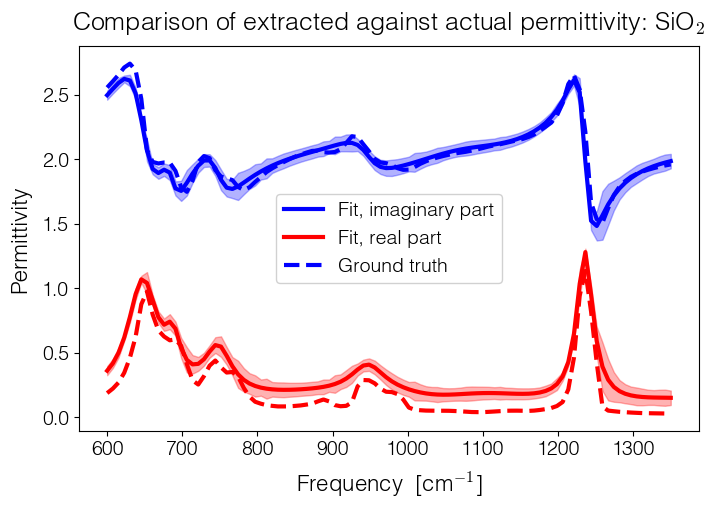

In [88]:
#---- Estimate the error / uncertainty in the extracted permittivity

pred_dev = np.abs(S_pred-S_targets) # Deviation of prediction from target, so the fit is definitely uncertain here
error_vs_meas = np.sqrt(pred_dev**2+S_targets_uncertainty**2) 
deps,dqp = MaterialModel.estimate_error(error_vs_meas,offset=.01)

eps_pred = MaterialModel.get_epss()
eps_freqs = MaterialModel.freqs

# --- Plot inferred permittivity in comparison to ground truth 

toplot=eps_pred.real
plt.plot(eps_freqs, toplot,color='b',label='Fit, imaginary part')
plt.fill_between(eps_freqs,toplot-deps/2,toplot+deps/2,color='b',alpha=.3)

toplot=eps_pred.imag
plt.plot(eps_freqs, toplot,color='r',label='Fit, real part')
plt.fill_between(eps_freqs,toplot-deps/2,toplot+deps/2,color='r',alpha=.3)

plt.plot(freqs_wn,eps_PMMA.real,ls='--',color='b',label='Ground truth')
plt.plot(freqs_wn,eps_PMMA.imag,ls='--',color='r')

plt.xlabel(r'Frequency  [cm$^{-1}$]')
plt.ylabel('Permittivity')
plt.title(r'Comparison of extracted against actual permittivity: PMMA')
plt.legend()

# --> Infer optical constants for bulk media directly with global fitting

## Set up an *extremeley fast* Predictor that is capable of predicting measurements from a bulk medium

In [26]:
# Awkwardly, the setup for `InvertibleEigenfieldsPredictor` is not (yet) uniform with other Predictors.. (2026.08.10)
#   So we have we have to change the units of these parameters first.
sim_kwargs2 = {}
conversion = P.get_a()/sim_kwargs['a_nm']
sim_kwargs2['zmin']=sim_kwargs['gapmin_nm']*conversion
sim_kwargs2['A']=sim_kwargs['amplitude_nm']*conversion
sim_kwargs2['Ngaps']=sim_kwargs['Ngaps']
sim_kwargs2['harmonic']=sim_kwargs['harmonic']

Predictor_S3_from_bulk = EI.InvertibleEigenfieldsPredictor(invertible_eigenfields=IE,
                                                           eps_ref = eps_ref, **sim_kwargs2)

## --> Infer optical constants for PMMA directly with global fitting

In [27]:
#-- Enable interactive plotting
# We need to use this matplotlib backend for interactive update of the fit result during the fitting process.
# This backend is installable from the eterminal with: `pip install ipympl`
%matplotlib widget

In [28]:
target_freqs = measured_S3_PMMA.axes[0]
Predictor = Predictor_S3_from_bulk

# Set up an "empty" material to hold our fitting results.  We can change all the details later.
from importlib import reload
reload(EI)
PMMA_MaterialModel = EI.VariationalMaterial2D(Predictor, target_freqs,
                                             Nosc_eps=20, amp_eps=0, eps0=1,
                                             Nosc_qp=3, amp_qp=0,
                                             eps_vals=None,
                                             qp_vals=None,
                                             additional_normalization=None) # Begin with no extra normalization.  Predictor has gold-normalization built-in to its constructor.  We can add SiO2 normalization later.

Recomputing basis of fine oscillators for permittivity...
Recomputing basis of fine oscillators for qp...


Fitting to a down-sampled set of 100 measurements...


/usr/local/Cellar/micromamba/2.8.1/envs/EigenProbe/lib/python3.9/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


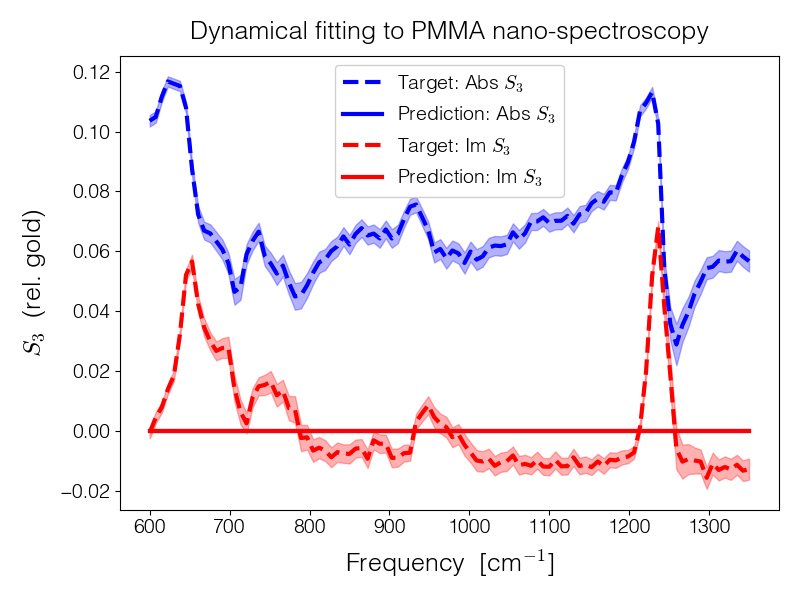

In [29]:
measured_S3 = measured_S3_PMMA
uncertainty = uncertainty_PMMA
MaterialModel=PMMA_MaterialModel

#-- Optionally down-sample data, which makes less work for the fitting
downsampling=1 # We may not be able to down-sample much, if we have many oscillators to fit.
S_targets = np.array(measured_S3[::downsampling])
S_targets_uncertainty = np.array(uncertainty[::downsampling])
target_freqs = measured_S3[::downsampling].axes[0]
MaterialModel.freqs = target_freqs # Correspondingly update the frequencies at which we wish to evaluate the model.
print('Fitting to a down-sampled set of %i measurements...'%len(target_freqs))

#---- Plot the prediction
S_pred = MaterialModel.predict(qps_enabled=True)

fig=plt.figure(figsize=(8,6))
plt.title('Dynamical fitting to PMMA nano-spectroscopy')
#plt.plot(target_fs,np.abs(target_spectra[sio2]),ls='--',color='b',label='Target for substrate')
#plt.plot(target_fs,np.abs(S_SiO2_pred),ls='-',color='b',label='Prediction for substrate')
toplot=np.abs(S_targets)
plt.plot(target_freqs,toplot,ls='--',color='b',label='Target: Abs $S_3$')
plt.fill_between(target_freqs,toplot-S_targets_uncertainty/2,toplot+S_targets_uncertainty/2,color='b',alpha=.3)
line_abs,=plt.plot(target_freqs,np.abs(S_pred),ls='-',color='b',label='Prediction: Abs $S_3$')

toplot=np.imag(S_targets)
plt.plot(target_freqs,toplot,ls='--',color='r',label='Target: Im $S_3$')
plt.fill_between(target_freqs,toplot-S_targets_uncertainty/2,toplot+S_targets_uncertainty/2,color='r',alpha=.3)
line_imag,=plt.plot(target_freqs,np.imag(S_pred),ls='-',color='r',label='Prediction: Im $S_3$')
plt.ylabel(r'$S_3$  (rel. gold)',fontsize=18)
plt.xlabel(r'Frequency  [cm$^{-1}$]',fontsize=18)
plt.legend()
plt.tight_layout()

MaterialModel.dynamic_plotting = dict(line_abs=line_abs,
                                      line_imag=line_imag,
                                      fig=fig,
                                      wait=1)

In [30]:
#--- Add a custom hook to the Material Model that will change the way results are dynamically plotted
def dynamic_plot_custom(self):

    try: kwargs = self.dynamic_plotting
    except AttributeError:
        raise AttributeError('To use dynamic plotting, attach a `dynamic_plotting` dictionary.')

    fig = kwargs['fig']
    line_abs = kwargs['line_abs']
    line_imag = kwargs['line_imag']

    S_pred = self.predict()
    line_abs.set_ydata(np.abs(S_pred))
    line_imag.set_ydata(np.imag(S_pred))
    fig.canvas.draw()

    # Save the image
    im_index = kwargs['im_index']
    num = f"{im_index:06d}"
    filepath=  'Imgs/'+num+'.png'
    print('Saving figure to "%s"...'%filepath)
    plt.savefig(filepath,dpi=300)
    kwargs['im_index']+=1

    if 'wait' in kwargs:
        import time
        time.sleep(kwargs['wait'])
        
#--- Attach the new dynamic plotting method to our Material Model
from types import MethodType
MaterialModel=PMMA_MaterialModel
MaterialModel.dynamic_plot = MethodType(dynamic_plot_custom, MaterialModel)
MaterialModel.dynamic_plotting['im_index']=0

In [31]:
measured_S3 = measured_S3_PMMA
uncertainty = uncertainty_PMMA

MaterialModel=PMMA_MaterialModel
MaterialModel.additional_normalization = None


#-- Optionally down-sample data, which makes less work for the fitting
downsampling=1 # We may not be able to down-sample much, if we have many oscillators to fit.
S_targets = np.array(measured_S3[::downsampling])
S_targets_uncertainty = np.array(uncertainty[::downsampling])
target_freqs = measured_S3[::downsampling].axes[0]
MaterialModel.freqs = target_freqs # Correspondingly update the frequencies at which we wish to evaluate the model.
print('Fitting to a down-sampled set of %i measurements...'%len(target_freqs))


optimize_coarse = True # It may or may not be that the previous step already provided a good coarse fit, so we can bypass refining the coarse fit
optimize_fine = True # Fine oscillators allow fitting every detail of the spectrum, but can lead to over-fitting when noise is large.
MaterialModel.set_fine_params_eps(Nosc=len(target_freqs)//2, amp=0) # Add (no more than) as many fine oscillators as there are measured frequencies

#----- Run the optimization
#@UPDATE: Choose whatever gives the best result
Nsupercycles=1 # Make this nonzero to actually run cycles of optimization, otherwise just plot the prediction
randomization=0 # Some randomization can "nudge" the fitting into a more global optimum
leastsq_kwargs = dict(factor=1,maxfev=100,ftol=1e-8,xtol=1e-8,epsfcn=1e-8) # These parameters are delivered to underlying `leastsq` optimizer; change whichever needed to "nudge" performance

# Feel free to keyboard interrupt at anytime, the loops will halt with forward progress saved in `MaterialModel`.
for i in range(Nsupercycles):
    print('Supercycle #%i..'%(i+1))

    if optimize_coarse:
        MaterialModel.optimize_eps_coarse(S_targets,S_targets_uncertainty,
                                             exp_start=0.5,exp_stop=2,
                                             Nsubcycles=3,Ncycles=3,
                                              randomization=randomization,
                                             **leastsq_kwargs)

    #--- Disable the fine optimization if we want 2D material properties to vary smoothly with frequency (no over-fitting)

    if optimize_fine:
        MaterialModel.optimize_eps_fine(S_targets,S_targets_uncertainty,
                                         exp_start=0.5,exp_stop=2,
                                         Nsubcycles=3,Ncycles=3,
                                          randomization=randomization,
                                         **leastsq_kwargs) 

Fitting to a down-sampled set of 100 measurements...
Recomputing basis of fine oscillators for permittivity...
Supercycle #1..
Optimizing "eps_coarse" with spectral normalization: None
Optimizing "eps_coarse" in cycle #1...
Optimizing "eps_coarse" in subcycle #1, exp=0.50...
R=23.35; time elapsed (s) in cycle: 0.16
Saving figure to "Imgs/000000.png"...
Optimizing "eps_coarse" in subcycle #2, exp=1.25...
R=14.61; time elapsed (s) in cycle: 0.24
Saving figure to "Imgs/000001.png"...
Optimizing "eps_coarse" in subcycle #3, exp=2.00...
R=8.67; time elapsed (s) in cycle: 0.22
Saving figure to "Imgs/000002.png"...
Optimizing "eps_coarse" in cycle #2...
Optimizing "eps_coarse" in subcycle #1, exp=0.50...
R=7.54; time elapsed (s) in cycle: 0.16
Saving figure to "Imgs/000003.png"...
Optimizing "eps_coarse" in subcycle #2, exp=1.25...
R=7.00; time elapsed (s) in cycle: 0.19
Saving figure to "Imgs/000004.png"...
Optimizing "eps_coarse" in subcycle #3, exp=2.00...
R=6.72; time elapsed (s) in cycle

Fitting to a down-sampled set of 100 measurements...


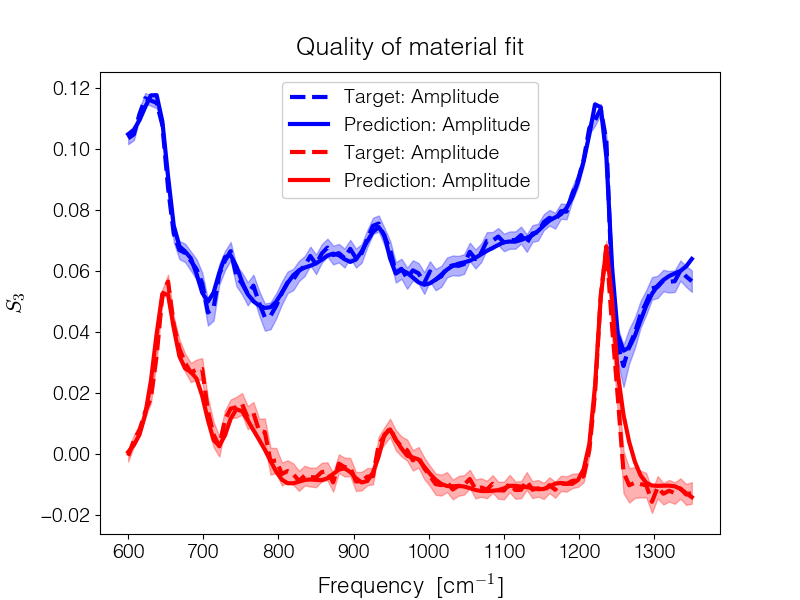

In [32]:
measured_S3 = measured_S3_PMMA
uncertainty = uncertainty_PMMA
MaterialModel=PMMA_MaterialModel

#-- Optionally down-sample data, which makes less work for the fitting
downsampling=1 # We may not be able to down-sample much, if we have many oscillators to fit.
S_targets = np.array(measured_S3[::downsampling])
S_targets_uncertainty = np.array(uncertainty[::downsampling])
target_freqs = measured_S3[::downsampling].axes[0]
MaterialModel.freqs = target_freqs # Correspondingly update the frequencies at which we wish to evaluate the model.
print('Fitting to a down-sampled set of %i measurements...'%len(target_freqs))

#---- Plot the prediction
S_pred = MaterialModel.predict(qps_enabled=True)

fig=plt.figure(figsize=(8,6))
plt.title('Quality of material fit')
#plt.plot(target_fs,np.abs(target_spectra[sio2]),ls='--',color='b',label='Target for substrate')
#plt.plot(target_fs,np.abs(S_SiO2_pred),ls='-',color='b',label='Prediction for substrate')
toplot=np.abs(S_targets)
plt.plot(target_freqs,toplot,ls='--',color='b',label='Target: Amplitude')
plt.fill_between(target_freqs,toplot-S_targets_uncertainty/2,toplot+S_targets_uncertainty/2,color='b',alpha=.3)
plt.plot(target_freqs,np.abs(S_pred),ls='-',color='b',label='Prediction: Amplitude')

toplot=np.imag(S_targets)
plt.plot(target_freqs,toplot,ls='--',color='r',label='Target: Amplitude')
plt.fill_between(target_freqs,toplot-S_targets_uncertainty/2,toplot+S_targets_uncertainty/2,color='r',alpha=.3)
plt.plot(target_freqs,np.imag(S_pred),ls='-',color='r',label='Prediction: Amplitude')
plt.ylabel(r'$S_3$')
plt.xlabel(r'Frequency  [cm$^{-1}$]')
plt.legend()

### Finally, compare the extracted PMMA permittivity against ground truth

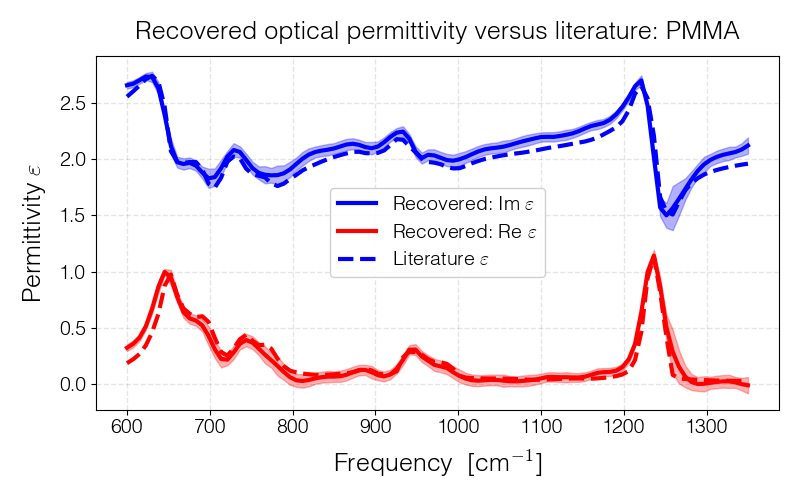

In [33]:
#---- Estimate the error / uncertainty in the extracted permittivity

pred_dev = np.abs(S_pred-S_targets) # Deviation of prediction from target, so the fit is definitely uncertain here
error_vs_meas = np.sqrt(pred_dev**2+S_targets_uncertainty**2) 
deps,dqp = MaterialModel.estimate_error(error_vs_meas,offset=.01) # Converts an error in output of model to corresponding error in input (permittivity)

eps_pred = MaterialModel.get_epss()
eps_freqs = MaterialModel.freqs


# --- Plot inferred permittivity in comparison to ground truth 

plt.figure()
toplot=eps_pred.real
offset=-.13
plt.plot(eps_freqs, toplot,color='b',label=r'Recovered: Im $\varepsilon$')
plt.fill_between(eps_freqs,toplot-deps/2,toplot+deps/2,color='b',alpha=.3)

toplot=eps_pred.imag+offset
plt.plot(eps_freqs, toplot,color='r',label=r'Recovered: Re $\varepsilon$')
plt.fill_between(eps_freqs,toplot-deps/2,toplot+deps/2,color='r',alpha=.3)

plt.plot(freqs_wn,eps_PMMA.real,ls='--',color='b',label=r'Literature $\varepsilon$')
plt.plot(freqs_wn,eps_PMMA.imag,ls='--',color='r')

plt.xlabel(r'Frequency  [cm$^{-1}$]',fontsize=18)
plt.ylabel(r'Permittivity $\varepsilon$',fontsize=18)
plt.title(r'Recovered optical permittivity versus literature: PMMA')
plt.legend()
plt.tight_layout()
plt.grid(alpha=.1)

## --> Infer optical constants for SiO2 directly with global fitting

In [208]:
#-- Enable interactive plotting
# We need to use this matplotlib backend for interactive update of the fit result during the fitting process.
# This backend is installable from the eterminal with: `pip install ipympl`
%matplotlib widget

In [220]:
target_freqs = measured_S3_SiO2.axes[0]
Predictor = Predictor_S3_from_layer

# Set up an "empty" material to hold our fitting results.  We can change all the details later.
SiO2_MaterialModel = EI.VariationalMaterial2D(Predictor, target_freqs,
                                             Nosc_eps=20, amp_eps=0, eps0=2,
                                             Nosc_qp=3, amp_qp=0,
                                             eps_vals=None,
                                             qp_vals=None,
                                             additional_normalization=None) # Begin with no extra normalization.  Predictor has gold-normalization built-in to its constructor.  We can add SiO2 normalization later.

Recomputing basis of fine oscillators for permittivity...
Recomputing basis of fine oscillators for qp...


Fitting to a down-sampled set of 100 measurements...


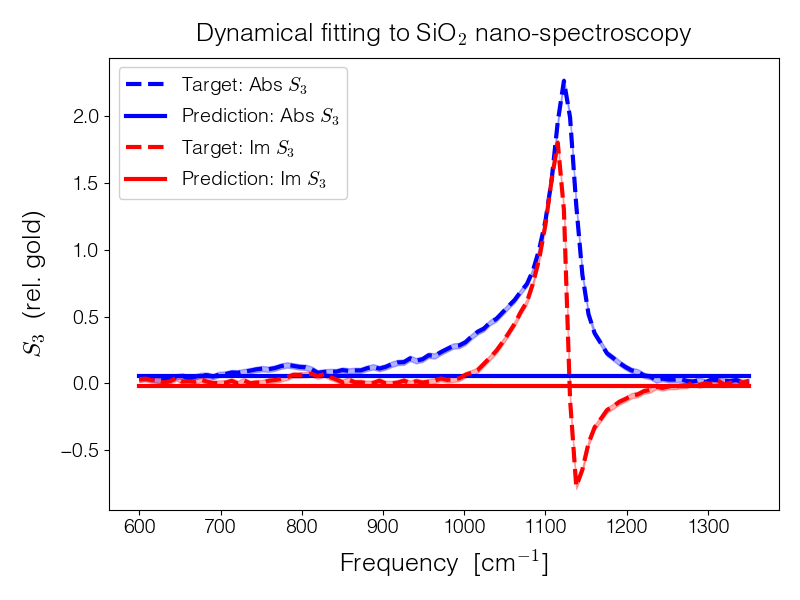

In [221]:
measured_S3 = measured_S3_SiO2
uncertainty = uncertainty_SiO2
MaterialModel=SiO2_MaterialModel

#-- Optionally down-sample data, which makes less work for the fitting
downsampling=1 # We may not be able to down-sample much, if we have many oscillators to fit.
S_targets = np.array(measured_S3[::downsampling])
S_targets_uncertainty = np.array(uncertainty[::downsampling])
target_freqs = measured_S3[::downsampling].axes[0]
MaterialModel.freqs = target_freqs # Correspondingly update the frequencies at which we wish to evaluate the model.
print('Fitting to a down-sampled set of %i measurements...'%len(target_freqs))

#---- Plot the prediction
S_pred = MaterialModel.predict(qps_enabled=True)

fig=plt.figure(figsize=(8,6))
plt.title('Dynamical fitting to SiO$_2$ nano-spectroscopy')
#plt.plot(target_fs,np.abs(target_spectra[sio2]),ls='--',color='b',label='Target for substrate')
#plt.plot(target_fs,np.abs(S_SiO2_pred),ls='-',color='b',label='Prediction for substrate')
toplot=np.abs(S_targets)
plt.plot(target_freqs,toplot,ls='--',color='b',label='Target: Abs $S_3$')
plt.fill_between(target_freqs,toplot-S_targets_uncertainty/2,toplot+S_targets_uncertainty/2,color='b',alpha=.3)
line_abs,=plt.plot(target_freqs,np.abs(S_pred),ls='-',color='b',label='Prediction: Abs $S_3$')

toplot=np.imag(S_targets)
plt.plot(target_freqs,toplot,ls='--',color='r',label='Target: Im $S_3$')
plt.fill_between(target_freqs,toplot-S_targets_uncertainty/2,toplot+S_targets_uncertainty/2,color='r',alpha=.3)
line_imag,=plt.plot(target_freqs,np.imag(S_pred),ls='-',color='r',label='Prediction: Im $S_3$')
plt.ylabel(r'$S_3$  (rel. gold)',fontsize=18)
plt.xlabel(r'Frequency  [cm$^{-1}$]',fontsize=18)
plt.legend()
plt.tight_layout()

MaterialModel.dynamic_plotting = dict(line_abs=line_abs,
                                      line_imag=line_imag,
                                      fig=fig,
                                      wait=1)

In [222]:
#--- Add a custom hook to the Material Model that will change the way results are dynamically plotted
MaterialModel=SiO2_MaterialModel

def dynamic_plot_custom(self):

    try: kwargs = self.dynamic_plotting
    except AttributeError:
        raise AttributeError('To use dynamic plotting, attach a `dynamic_plotting` dictionary.')

    fig = kwargs['fig']
    line_abs = kwargs['line_abs']
    line_imag = kwargs['line_imag']

    S_pred = self.predict()
    line_abs.set_ydata(np.abs(S_pred))
    line_imag.set_ydata(np.imag(S_pred))
    fig.canvas.draw()

    # Save the image
    im_index = kwargs['im_index']
    num = f"{im_index:06d}"
    filepath=  'Imgs/'+num+'.png'
    print('Saving figure to "%s"...'%filepath)
    plt.savefig(filepath,dpi=300)
    kwargs['im_index']+=1

    if 'wait' in kwargs:
        import time
        time.sleep(kwargs['wait'])
        
#--- Attach the new dynamic plotting method to our Material Model
from types import MethodType
MaterialModel.dynamic_plot = MethodType(dynamic_plot_custom, MaterialModel)
MaterialModel.dynamic_plotting['im_index']=0

In [223]:
measured_S3 = measured_S3_SiO2
uncertainty = uncertainty_SiO2

MaterialModel=SiO2_MaterialModel
MaterialModel.additional_normalization = None


#-- Optionally down-sample data, which makes less work for the fitting
downsampling=1 # We may not be able to down-sample much, if we have many oscillators to fit.
S_targets = np.array(measured_S3[::downsampling])
S_targets_uncertainty = np.array(uncertainty[::downsampling])
target_freqs = measured_S3[::downsampling].axes[0]
MaterialModel.freqs = target_freqs # Correspondingly update the frequencies at which we wish to evaluate the model.
print('Fitting to a down-sampled set of %i measurements...'%len(target_freqs))


optimize_coarse = True # It may or may not be that the previous step already provided a good coarse fit, so we can bypass refining the coarse fit
optimize_fine = True # Fine oscillators allow fitting every detail of the spectrum, but can lead to over-fitting when noise is large.
MaterialModel.set_fine_params_eps(Nosc=len(target_freqs)//2, amp=0) # Add (no more than) as many fine oscillators as there are measured frequencies

#----- Run the optimization
#@UPDATE: Choose whatever gives the best result
Nsupercycles=1 # Make this nonzero to actually run cycles of optimization, otherwise just plot the prediction
randomization=0 # Some randomization can "nudge" the fitting into a more global optimum
leastsq_kwargs = dict(factor=1,maxfev=100,ftol=1e-8,xtol=1e-8,epsfcn=1e-8) # These parameters are delivered to underlying `leastsq` optimizer; change whichever needed to "nudge" performance

# Feel free to keyboard interrupt at anytime, the loops will halt with forward progress saved in `MaterialModel`.
for i in range(Nsupercycles):
    print('Supercycle #%i..'%(i+1))

    if optimize_coarse:
        MaterialModel.optimize_eps_coarse(S_targets,S_targets_uncertainty,
                                             exp_start=0.5,exp_stop=2,
                                             Nsubcycles=3,Ncycles=3,
                                              randomization=randomization,
                                             **leastsq_kwargs)

    #--- Disable the fine optimization if we want 2D material properties to vary smoothly with frequency (no over-fitting)

    if optimize_fine:
        MaterialModel.optimize_eps_fine(S_targets,S_targets_uncertainty,
                                         exp_start=0.5,exp_stop=2,
                                         Nsubcycles=3,Ncycles=3,
                                          randomization=randomization,
                                         **leastsq_kwargs) 

Fitting to a down-sampled set of 100 measurements...
Recomputing basis of fine oscillators for permittivity...
Supercycle #1..
Optimizing "eps_coarse" with spectral normalization: None
Optimizing "eps_coarse" in cycle #1...
Optimizing "eps_coarse" in subcycle #1, exp=0.50...
R=33.23; time elapsed (s) in cycle: 56.00
Saving figure to "Imgs/000000.png"...
Optimizing "eps_coarse" in subcycle #2, exp=1.25...
Aborting optimization (with forward progress)...
Time elapsed (s) for optimization: 71.18911290168762


KeyboardInterrupt: 

Fitting to a down-sampled set of 100 measurements...


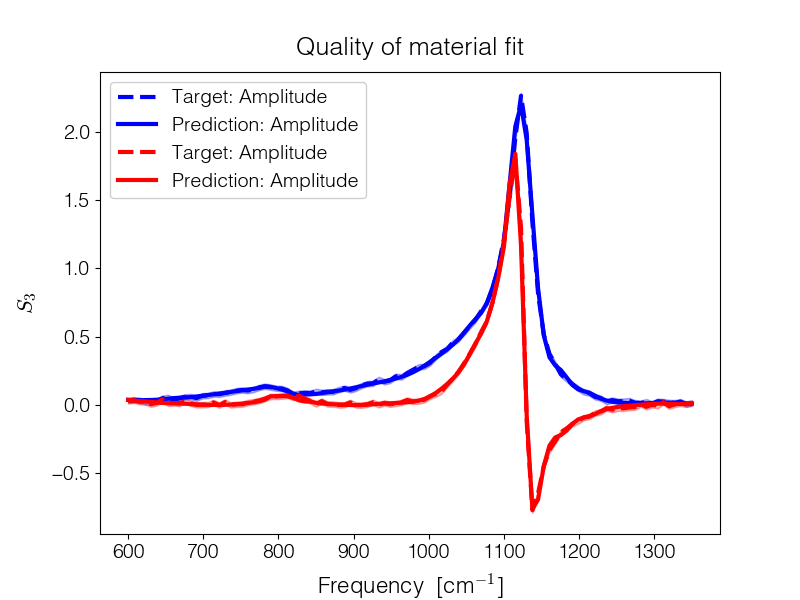

In [213]:
measured_S3 = measured_S3_SiO2
uncertainty = uncertainty_SiO2
MaterialModel=SiO2_MaterialModel

#-- Optionally down-sample data, which makes less work for the fitting
downsampling=1 # We may not be able to down-sample much, if we have many oscillators to fit.
S_targets = np.array(measured_S3[::downsampling])
S_targets_uncertainty = np.array(uncertainty[::downsampling])
target_freqs = measured_S3[::downsampling].axes[0]
MaterialModel.freqs = target_freqs # Correspondingly update the frequencies at which we wish to evaluate the model.
print('Fitting to a down-sampled set of %i measurements...'%len(target_freqs))

#---- Plot the prediction
S_pred = MaterialModel.predict(qps_enabled=True)

fig=plt.figure(figsize=(8,6))
plt.title('Quality of material fit')
#plt.plot(target_fs,np.abs(target_spectra[sio2]),ls='--',color='b',label='Target for substrate')
#plt.plot(target_fs,np.abs(S_SiO2_pred),ls='-',color='b',label='Prediction for substrate')
toplot=np.abs(S_targets)
plt.plot(target_freqs,toplot,ls='--',color='b',label='Target: Amplitude')
plt.fill_between(target_freqs,toplot-S_targets_uncertainty/2,toplot+S_targets_uncertainty/2,color='b',alpha=.3)
plt.plot(target_freqs,np.abs(S_pred),ls='-',color='b',label='Prediction: Amplitude')

toplot=np.imag(S_targets)
plt.plot(target_freqs,toplot,ls='--',color='r',label='Target: Amplitude')
plt.fill_between(target_freqs,toplot-S_targets_uncertainty/2,toplot+S_targets_uncertainty/2,color='r',alpha=.3)
plt.plot(target_freqs,np.imag(S_pred),ls='-',color='r',label='Prediction: Amplitude')
plt.ylabel(r'$S_3$')
plt.xlabel(r'Frequency  [cm$^{-1}$]')
plt.legend()

### Finally, compare the extracted SiO2 permittivity against ground truth

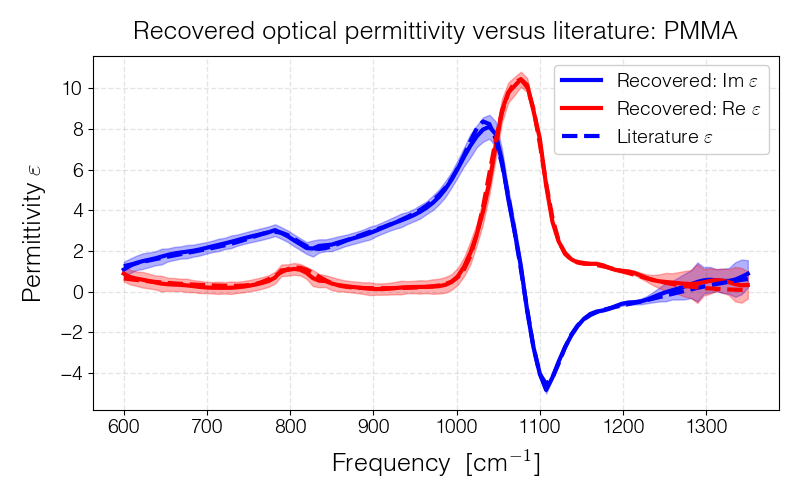

In [215]:
#---- Estimate the error / uncertainty in the extracted permittivity

pred_dev = np.abs(S_pred-S_targets) # Deviation of prediction from target, so the fit is definitely uncertain here
error_vs_meas = np.sqrt(pred_dev**2+S_targets_uncertainty**2) 
deps,dqp = MaterialModel.estimate_error(error_vs_meas,offset=.01) # Converts an error in output of model to corresponding error in input (permittivity)

eps_pred = MaterialModel.get_epss()
eps_freqs = MaterialModel.freqs


# --- Plot inferred permittivity in comparison to ground truth 

plt.figure()
toplot=eps_pred.real
offset=0
plt.plot(eps_freqs, toplot,color='b',label=r'Recovered: Im $\varepsilon$')
plt.fill_between(eps_freqs,toplot-deps/2,toplot+deps/2,color='b',alpha=.3)

toplot=eps_pred.imag+offset
plt.plot(eps_freqs, toplot,color='r',label=r'Recovered: Re $\varepsilon$')
plt.fill_between(eps_freqs,toplot-deps/2,toplot+deps/2,color='r',alpha=.3)

plt.plot(freqs_wn,eps_SiO2.real,ls='--',color='b',label=r'Literature $\varepsilon$')
plt.plot(freqs_wn,eps_SiO2.imag,ls='--',color='r')

plt.xlabel(r'Frequency  [cm$^{-1}$]',fontsize=18)
plt.ylabel(r'Permittivity $\varepsilon$',fontsize=18)
plt.title(r'Recovered optical permittivity versus literature: PMMA')
plt.legend()
plt.tight_layout()
plt.grid(alpha=.1)